# 📋 Fichas por Categoría de Edad — Toques / min (GLMM M2)

**Notebook complementario a `01_glmm_toques.ipynb`**

Este notebook presenta **fichas visuales independientes** para cada grupo de edad,
basadas en las **Medias Marginales Estimadas (EMMs)** del modelo GLMM bayesiano
M2 (Gamma, log-link, efectos aleatorios por jugador).

Cada ficha muestra tres paneles:

| Panel | Contenido |
|-------|-----------|
| **Izquierdo** | EMMs por nivel de cada VI de diseño (con HDI 95 %) |
| **Derecho** | Impacto absoluto (Δ) de cada VI, ordenado por magnitud |
| **Inferior** | 4 escenarios combinados de diseño de tarea |

<br>

> 🔑 Los modelos M1 y M2 se **ajustan directamente** en este notebook a partir
> de los datos fuente. No hay datos hardcodeados: los EMMs se calculan
> dinámicamente a partir de la posterior bayesiana.

In [1]:
# ══════════════════════════════════════════════════════════════════════════
#  CELDA 1 — Imports y carga de datos
# ══════════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import bambi as bmb
import arviz as az
import pymc as pm

az.style.use("arviz-darkgrid")
%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 10,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# ── Carga de datos ───────────────────────────────────────────────────────
df = pd.read_excel("../Datos/Matriz_V3.xlsx")

rename_map = {
    "Total Touches / min": "ToquesMin",
    "Player Id": "PlayerId",
}
df = df.rename(columns=rename_map)

for col in ["Formato_del_Juego", "Polaridad", "Equilibrio",
            "GrupoEdad", "PlayerId"]:
    df[col] = df[col].astype("category")

print(f"✅ Datos cargados: {df.shape[0]} obs × {df.shape[1]} columnas")
print(f"   Jugadores únicos: {df['PlayerId'].nunique()}")
print(f"   Categorías de edad: {sorted(df['GrupoEdad'].cat.categories.tolist())}")

✅ Datos cargados: 3179 obs × 18 columnas
   Jugadores únicos: 249
   Categorías de edad: ['Cadete', 'Infantil', 'Juvenil', 'Neskak', 'Senior Masculino']


In [2]:
# ══════════════════════════════════════════════════════════════════════════
#  CELDA 2 — Carga de resultados res1 y res2 previamente ajustados
# ══════════════════════════════════════════════════════════════════════════

# ── Cargar res1 y res2 desde 01_glmm_toques.ipynb ────────────────────────
print("📂 Cargando resultados res1 y res2 previamente ajustados...")
res1 = az.from_netcdf("../Datos/Modelos/res1_toques.nc")
print("✅ res1 cargado")

res2 = az.from_netcdf("../Datos/Modelos/res2_toques.nc")
print("✅ res2 cargado")

# ── Reconstruir modelos m1 y m2 (solo estructura, sin ajustar) ───────────
print("\n🔧 Reconstruyendo modelos m1 y m2...")
m1 = bmb.Model(
    "ToquesMin ~ Formato_del_Juego + Polaridad + Equilibrio + (1|PlayerId)",
    df, family="gamma", link="log"
)
m2 = bmb.Model(
    "ToquesMin ~ Formato_del_Juego + Polaridad + Equilibrio + GrupoEdad + (1|PlayerId)",
    df, family="gamma", link="log"
)
print("✅ Modelos reconstruidos")

# ── Verificación rápida de convergencia ──────────────────────────────────
rhat_m1 = az.rhat(res1)
rhat_m2 = az.rhat(res2)
print(f"\nR-hat máximo M1: {max(rhat_m1.max().values()):.4f}")
print(f"R-hat máximo M2: {max(rhat_m2.max().values()):.4f}")

📂 Cargando resultados res1 y res2 previamente ajustados...
✅ res1 cargado
✅ res2 cargado

🔧 Reconstruyendo modelos m1 y m2...
✅ Modelos reconstruidos

R-hat máximo M1: 1.0026
R-hat máximo M2: 1.0037


In [3]:
# ══════════════════════════════════════════════════════════════════════════
#  CELDA 3 — Extracción de posteriors, cálculo de EMMs y función ficha
# ══════════════════════════════════════════════════════════════════════════
from itertools import product

# ── Niveles de cada VI ───────────────────────────────────────────────────
niveles_vi = {
    "Formato_del_Juego": ["LSG", "SSG"],
    "Polaridad":         ["NoPolarizado", "Polarizado"],
    "Equilibrio":        ["Desequilibrio", "Equilibrio"],
}

# ── Niveles de GrupoEdad (detección dinámica) ───────────────────────────
_ge_dim = [d for d in res2.posterior["GrupoEdad"].dims if d not in ("chain", "draw")][0]
_ge_post = [str(lv) for lv in res2.posterior["GrupoEdad"].coords[_ge_dim].values]
_ge_all  = sorted(df["GrupoEdad"].cat.categories)
_ge_ref  = [lv for lv in _ge_all if lv not in _ge_post]
niveles_ge = sorted(_ge_ref + _ge_post)

# ── Muestras posteriores M2 ─────────────────────────────────────────────
post2 = res2.posterior
n_samples = post2.dims["chain"] * post2.dims["draw"]

intercept_m2 = post2["Intercept"].values.flatten()
betas_m2 = {vi: post2[vi].values.flatten() for vi in niveles_vi}

ge_dim = [d for d in post2["GrupoEdad"].dims if d not in ("chain", "draw")][0]
ge_post_levels = [str(lv) for lv in post2["GrupoEdad"].coords[ge_dim].values]
betas_ge = {}
for i, lev in enumerate(ge_post_levels):
    betas_ge[lev] = post2["GrupoEdad"].values[:, :, i].flatten()
for ref_lev in _ge_ref:
    betas_ge[ref_lev] = np.zeros(n_samples)

print(f"Muestras posteriores: {n_samples}")
print(f"GrupoEdad — ref: {_ge_ref}, no-ref: {ge_post_levels}")
print(f"niveles_ge: {niveles_ge}")


# ── Función EMM ──────────────────────────────────────────────────────────
def calcular_emm(target_levels, betas, intercept, all_niveles,
                 betas_ge=None, ge_level=None):
    """
    Distribución posterior de la EMM para una combinación de niveles,
    marginalizando sobre los demás factores con ponderación uniforme.
    """
    marg = {k: v for k, v in all_niveles.items() if k not in target_levels}
    if marg:
        marg_combos = list(product(*marg.values()))
        marg_keys = list(marg.keys())
    else:
        marg_combos = [()]
        marg_keys = []
    ref = {k: sorted(v)[0] for k, v in all_niveles.items()}
    n = len(intercept)
    emm = np.zeros(n)
    for combo in marg_combos:
        log_mu = intercept.copy()
        for factor, level in target_levels.items():
            if level != ref[factor]:
                log_mu += betas[factor]
        for factor, level in zip(marg_keys, combo):
            if level != ref[factor]:
                log_mu += betas[factor]
        if betas_ge is not None and ge_level is not None:
            log_mu += betas_ge[ge_level]
        emm += np.exp(log_mu)
    emm /= len(marg_combos)
    return emm


def emm_tabla(emm_samples):
    """Retorna (media, hdi_lo, hdi_hi)."""
    return np.mean(emm_samples), *az.hdi(emm_samples, hdi_prob=0.95)


# ══════════════════════════════════════════════════════════════════════════
#  CÁLCULO AUTOMÁTICO DE emm_global y emm_vi_ge
# ══════════════════════════════════════════════════════════════════════════

etiquetas_vi = {
    "Formato_del_Juego": "Formato del Juego",
    "Polaridad": "Polaridad", "Equilibrio": "Equilibrio",
}

# ── EMM global por GrupoEdad ────────────────────────────────────────────
emm_global = {}
for ge in niveles_ge:
    samples = calcular_emm({}, betas_m2, intercept_m2, niveles_vi,
                           betas_ge=betas_ge, ge_level=ge)
    emm_global[ge] = emm_tabla(samples)

print("\n── EMM global por GrupoEdad ──")
for ge, (m, lo, hi) in emm_global.items():
    print(f"  {ge:20s}  {m:.3f}  [{lo:.3f}, {hi:.3f}]")

# ── EMMs por VI × GrupoEdad ─────────────────────────────────────────────
emm_vi_ge = {}
for cat in niveles_ge:
    emm_vi_ge[cat] = {}
    for vi in niveles_vi:
        emm_vi_ge[cat][etiquetas_vi[vi]] = {}
        for nivel in niveles_vi[vi]:
            samples = calcular_emm({vi: nivel}, betas_m2, intercept_m2,
                                   niveles_vi, betas_ge=betas_ge, ge_level=cat)
            emm_vi_ge[cat][etiquetas_vi[vi]][nivel] = emm_tabla(samples)

print("\n✅ emm_global y emm_vi_ge calculados dinámicamente a partir de la posterior")


# ══════════════════════════════════════════════════════════════════════════
#  CONSTANTES DE VISUALIZACIÓN Y FUNCIONES
# ══════════════════════════════════════════════════════════════════════════

nivel_boost = {
    "Polaridad": "NoPolarizado", "Formato del Juego": "SSG",
    "Equilibrio": "Desequilibrio",
}
nivel_reduce = {
    "Polaridad": "Polarizado",   "Formato del Juego": "LSG",
    "Equilibrio": "Equilibrio",
}
etiquetas_nivel = {
    "NoPolarizado": "No Polarizado", "Polarizado": "Polarizado",
    "SSG": "SSG (Reducido)",         "LSG": "LSG (Amplio)",
    "reducido": "Reducido",          "amplio": "Amplio",
    "pequeño": "Pequeño (≤4v≤4)",    "grande": "Grande (≥5v≥5)",
    "Desequilibrio": "Desequilibrio","Equilibrio": "Equilibrio",
}
orden_vi = ["Polaridad", "Formato del Juego", "Equilibrio"]

# Paleta amplia: se asigna un color a cada categoría detectada
_paleta_base = ["#1B9E77", "#D95F02", "#7570B3", "#E7298A", "#66A61E",
                "#E6AB02", "#A6761D", "#666666"]
colores_cat = {cat: _paleta_base[i % len(_paleta_base)]
               for i, cat in enumerate(sorted(niveles_ge))}
COLOR_BOOST  = "#2C7BB6"
COLOR_REDUCE = "#FDAE61"
COLOR_NS     = "#BDBDBD"
ESC_COLORES  = ["#4575B4", "#91BFDB", "#FC8D59", "#D73027"]

orden_categorias = sorted(niveles_ge, key=lambda x: emm_global[x][0], reverse=True)


def calcular_escenarios(cat):
    """Devuelve 4 escenarios: máximo, favorable, desfavorable, mínimo."""
    g = emm_global[cat][0]
    vi = emm_vi_ge[cat]
    r_b = {v: vi[v][nivel_boost[v]][0]  / g for v in orden_vi}
    r_r = {v: vi[v][nivel_reduce[v]][0] / g for v in orden_vi}
    return [
        ("Máximo estímulo",
         g * r_b["Polaridad"] * r_b["Formato del Juego"] * r_b["Equilibrio"],
         "NoPol · Reduc · Peq · Deseq"),
        ("Favorable (top-2 VI)",
         g * r_b["Polaridad"] * r_b["Formato del Juego"] * r_r["Equilibrio"],
         "NoPol · Reduc · Gra · Equil"),
        ("Desfavorable (top-2 ×)",
         g * r_r["Polaridad"] * r_r["Formato del Juego"] * r_b["Equilibrio"],
         "Pol · Amp · Peq · Deseq"),
        ("Mínimo estímulo",
         g * r_r["Polaridad"] * r_r["Formato del Juego"] * r_r["Equilibrio"],
         "Pol · Amp · Gra · Equil"),
    ]


def generar_ficha(categoria):
    """
    Genera una ficha visual de 3 paneles para una categoría de edad.
    """
    vi_data     = emm_vi_ge[categoria]
    glob        = emm_global[categoria]
    escenarios  = calcular_escenarios(categoria)
    color       = colores_cat[categoria]

    fig = plt.figure(figsize=(18, 11), facecolor="white")
    fig.suptitle(f"📋  Ficha de Diseño de Tareas — {categoria}",
                 fontsize=19, fontweight="bold", y=0.98, color=color)

    gs = gridspec.GridSpec(2, 2, height_ratios=[3, 1.6],
                           hspace=0.35, wspace=0.30,
                           left=0.10, right=0.96, top=0.92, bottom=0.06)

    # ── PANEL 1: EMMs por nivel de cada VI ───────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
    y = 0
    yticks, ytick_labels = [], []
    vi_label_positions = []
    for vi in reversed(orden_vi):
        for is_boost, nk in [(False, nivel_reduce[vi]),
                             (True,  nivel_boost[vi])]:
            emm, lo, hi = vi_data[vi][nk]
            c = COLOR_NS if vi == "Equilibrio" else (COLOR_BOOST if is_boost else COLOR_REDUCE)
            ax1.barh(y, emm, height=0.62, color=c, alpha=0.85,
                     edgecolor="white", linewidth=0.5)
            ax1.errorbar(emm, y, xerr=[[emm - lo], [hi - emm]],
                         fmt="none", ecolor="#333", elinewidth=1, capsize=3)
            ax1.text(emm + 0.04, y, f"{emm:.2f}", va="center", fontsize=9,
                     fontweight="bold")
            yticks.append(y)
            ytick_labels.append(etiquetas_nivel[nk])
            y += 1
        vi_label_positions.append(((y - 1.5), vi))
        y += 1.2
    ax1.axvline(glob[0], color=color, lw=1.8, ls="--", alpha=0.7, zorder=0,
                label=f"Media global = {glob[0]:.2f}")
    ax1.set_yticks(yticks)
    ax1.set_yticklabels(ytick_labels, fontsize=9)
    for yc, vi_name in vi_label_positions:
        ax1.annotate(vi_name, xy=(-0.02, yc), xycoords=("axes fraction", "data"),
                     fontsize=10.5, fontweight="bold", ha="right", va="center",
                     color="#444444")
    ax1.set_xlabel("Toques / min (EMM)", fontsize=11)
    ax1.set_title("EMMs por Variable de Diseño", fontsize=14,
                  fontweight="bold", pad=12)
    ax1.legend(fontsize=9, loc="lower right", framealpha=0.8)
    ax1.set_xlim(left=0)
    ax1.grid(axis="x", alpha=0.25, ls=":")
    ax1.spines[["top", "right"]].set_visible(False)

    # ── PANEL 2: Impacto absoluto Δ ──────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
    deltas, pcts, d_colors = [], [], []
    for vi in orden_vi:
        emm_b = vi_data[vi][nivel_boost[vi]][0]
        emm_r = vi_data[vi][nivel_reduce[vi]][0]
        deltas.append(emm_b - emm_r)
        pcts.append((emm_b / emm_r - 1) * 100)
        d_colors.append(COLOR_NS if vi == "Equilibrio" else COLOR_BOOST)
    y_d = np.arange(len(orden_vi))
    ax2.barh(y_d, deltas, height=0.55, color=d_colors, alpha=0.85,
             edgecolor="white", linewidth=0.5)
    for i, (d, p) in enumerate(zip(deltas, pcts)):
        txt_c = "#333" if orden_vi[i] != "Equilibrio" else "#999"
        ax2.text(d + 0.03, i, f"+{d:.2f}  ({p:+.0f} %)",
                 va="center", fontsize=10.5, fontweight="bold", color=txt_c)
        if orden_vi[i] == "Equilibrio":
            ax2.text(d + 0.03, i - 0.30, "(n.s.)", fontsize=8, color="#999",
                     fontstyle="italic")
    ax2.set_yticks(y_d)
    ax2.set_yticklabels(orden_vi, fontsize=11, fontweight="bold")
    ax2.set_xlabel("Δ Toques / min", fontsize=11)
    ax2.set_title("Impacto Absoluto por VI\n(nivel ↑toques − nivel ↓toques)",
                  fontsize=14, fontweight="bold", pad=12)
    ax2.set_xlim(left=0, right=max(deltas) * 1.55)
    ax2.grid(axis="x", alpha=0.25, ls=":")
    ax2.spines[["top", "right"]].set_visible(False)

    # ── PANEL 3: Escenarios combinados ───────────────────────────────────
    ax3 = fig.add_subplot(gs[1, :])
    esc_nombres = [e[0] for e in escenarios]
    esc_valores = [e[1] for e in escenarios]
    esc_desc    = [e[2] for e in escenarios]
    y_e = np.arange(len(escenarios))
    bars = ax3.barh(y_e, esc_valores, height=0.52, color=ESC_COLORES,
                    alpha=0.88, edgecolor="white", linewidth=0.5)
    for i, (nombre, val, desc) in enumerate(escenarios):
        ax3.text(val + 0.06, i, f" {val:.2f} tq/min", va="center",
                 fontsize=11, fontweight="bold", color=ESC_COLORES[i])
        ax3.text(0.15, i, desc, va="center", fontsize=8.5,
                 color="white", fontweight="bold", fontstyle="italic")
    ax3.set_yticks(y_e)
    ax3.set_yticklabels(esc_nombres, fontsize=10, fontweight="bold")
    ax3.set_xlabel("Toques / min (EMM predicho)", fontsize=11)
    ax3.set_title("Escenarios Combinados de Diseño de Tarea",
                  fontsize=14, fontweight="bold", pad=12)
    ax3.set_xlim(left=0, right=max(esc_valores) * 1.18)
    ax3.grid(axis="x", alpha=0.25, ls=":")
    ax3.spines[["top", "right"]].set_visible(False)
    ax3.invert_yaxis()
    plt.show()
    return fig


print("\n✅ Funciones de visualización listas")
print(f"   Categorías (↓EMM): {orden_categorias}")
print(f"   Escenarios de ejemplo (Infantil):")
for n, v, d in calcular_escenarios("Infantil"):
    print(f"     {n:28s}  →  {v:.2f} tq/min  ({d})")

Muestras posteriores: 8000
GrupoEdad — ref: ['Cadete'], no-ref: ['Infantil', 'Juvenil', 'Neskak', 'Senior Masculino']
niveles_ge: ['Cadete', 'Infantil', 'Juvenil', 'Neskak', 'Senior Masculino']

── EMM global por GrupoEdad ──
  Cadete                2.958  [2.748, 3.178]
  Infantil              3.142  [2.882, 3.395]
  Juvenil               2.347  [2.195, 2.500]
  Neskak                2.814  [2.639, 3.002]
  Senior Masculino      2.237  [2.092, 2.378]

✅ emm_global y emm_vi_ge calculados dinámicamente a partir de la posterior

✅ Funciones de visualización listas
   Categorías (↓EMM): ['Infantil', 'Cadete', 'Neskak', 'Juvenil', 'Senior Masculino']
   Escenarios de ejemplo (Infantil):
     Máximo estímulo               →  4.64 tq/min  (NoPol · Reduc · Peq · Deseq)
     Favorable (top-2 VI)          →  4.60 tq/min  (NoPol · Reduc · Gra · Equil)
     Desfavorable (top-2 ×)        →  1.93 tq/min  (Pol · Amp · Peq · Deseq)
     Mínimo estímulo               →  1.91 tq/min  (Pol · Amp · Gra ·

---
## Fichas individuales por categoría de edad

Se genera automáticamente una ficha por cada nivel de `GrupoEdad` detectado
en los datos, ordenadas de mayor a menor EMM global.


════════════════════════════════════════════════════════════
  1 · Infantil  —  EMM global: 3.14 tq/min  [2.88, 3.40]
════════════════════════════════════════════════════════════


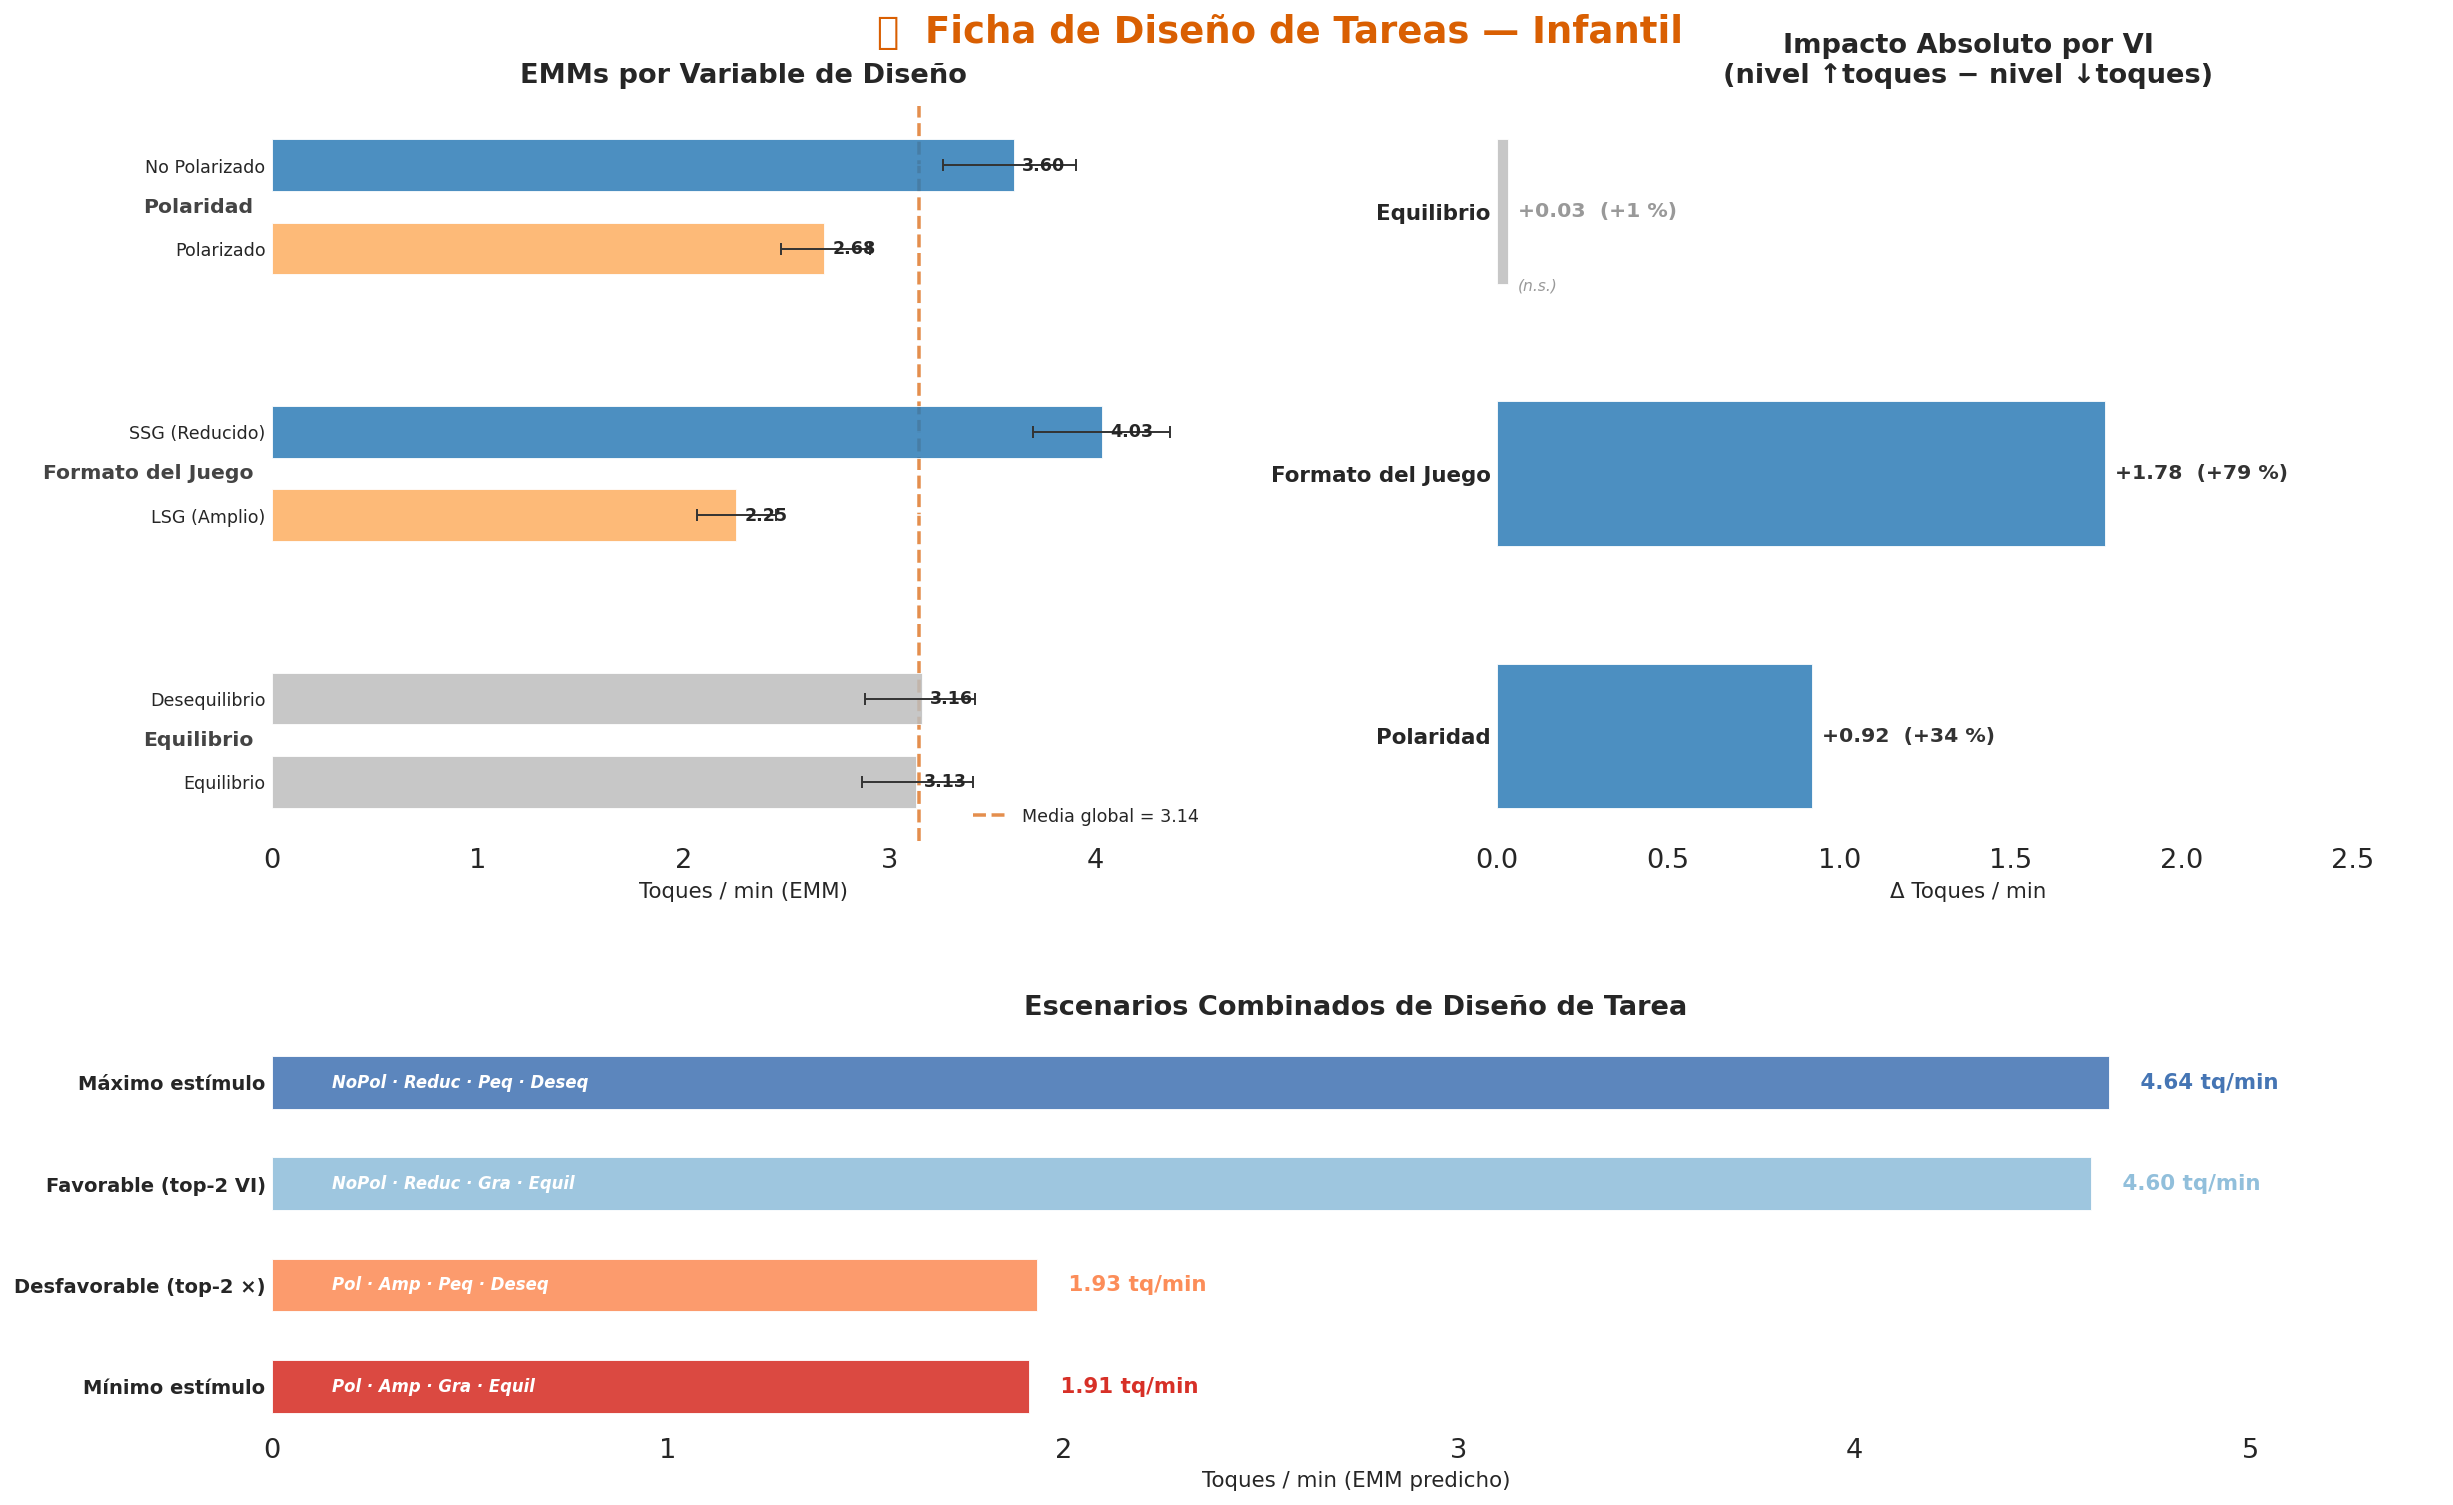


════════════════════════════════════════════════════════════
  2 · Cadete  —  EMM global: 2.96 tq/min  [2.75, 3.18]
════════════════════════════════════════════════════════════


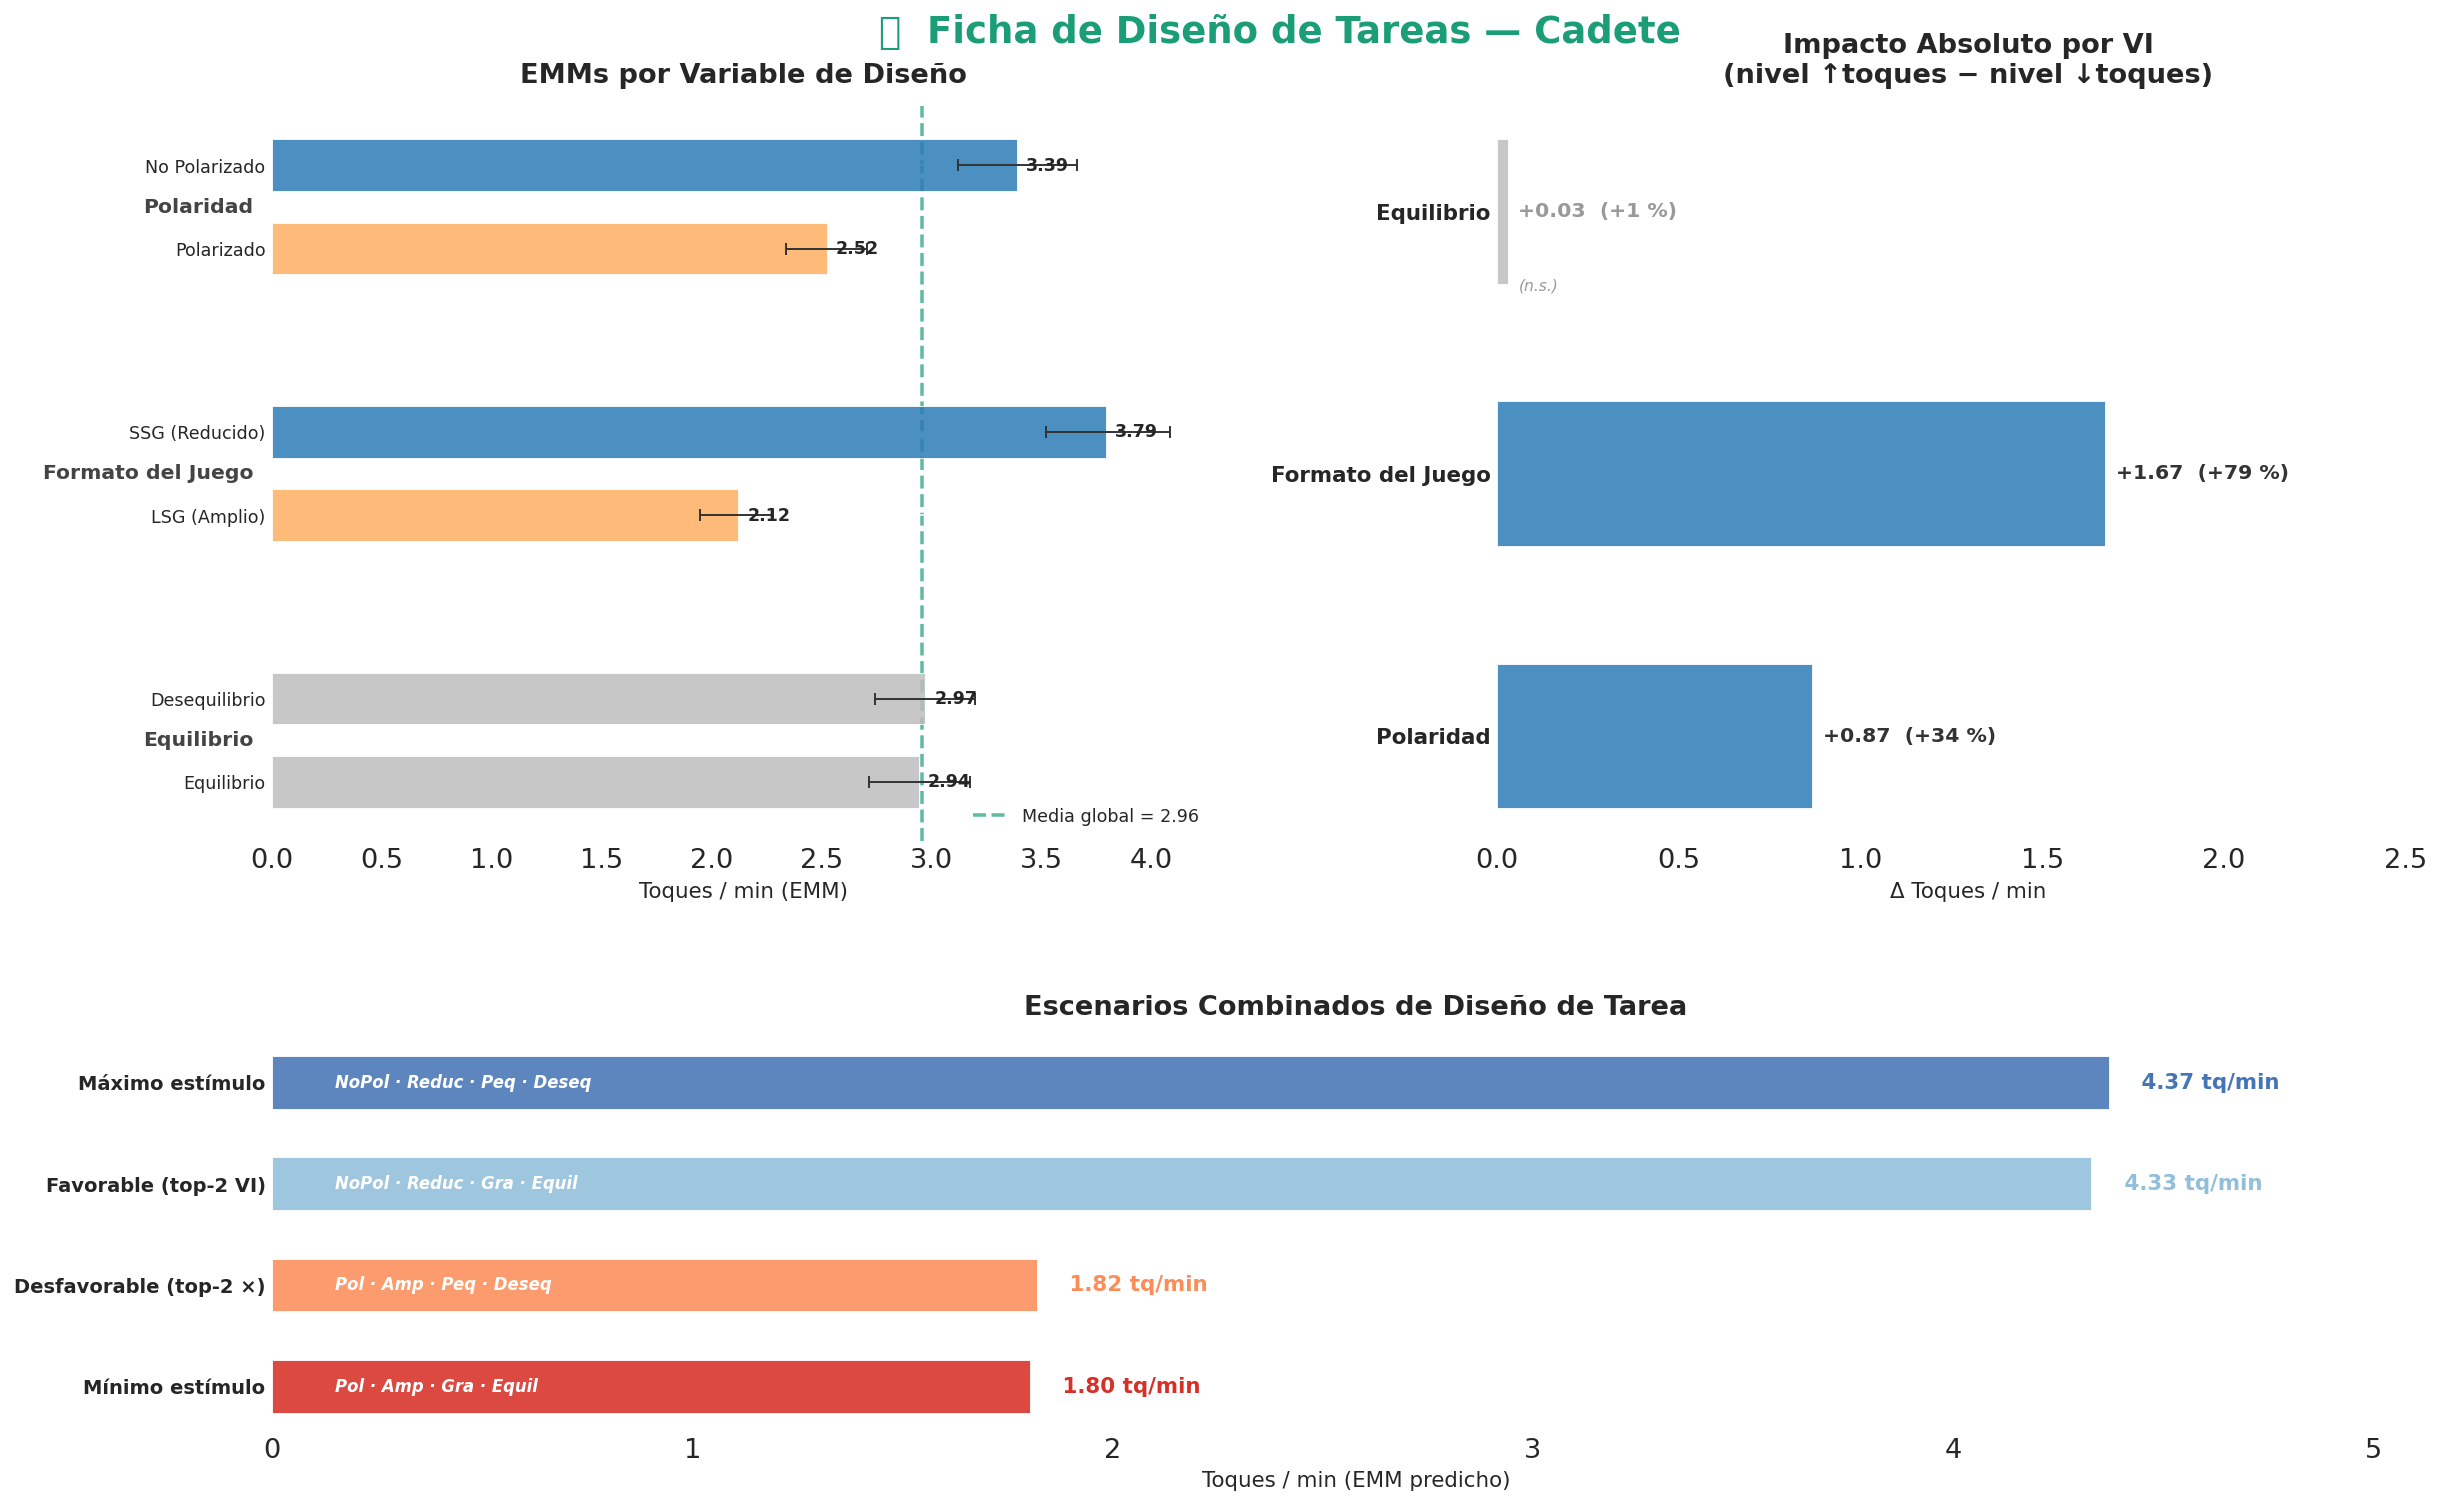


════════════════════════════════════════════════════════════
  3 · Neskak  —  EMM global: 2.81 tq/min  [2.64, 3.00]
════════════════════════════════════════════════════════════


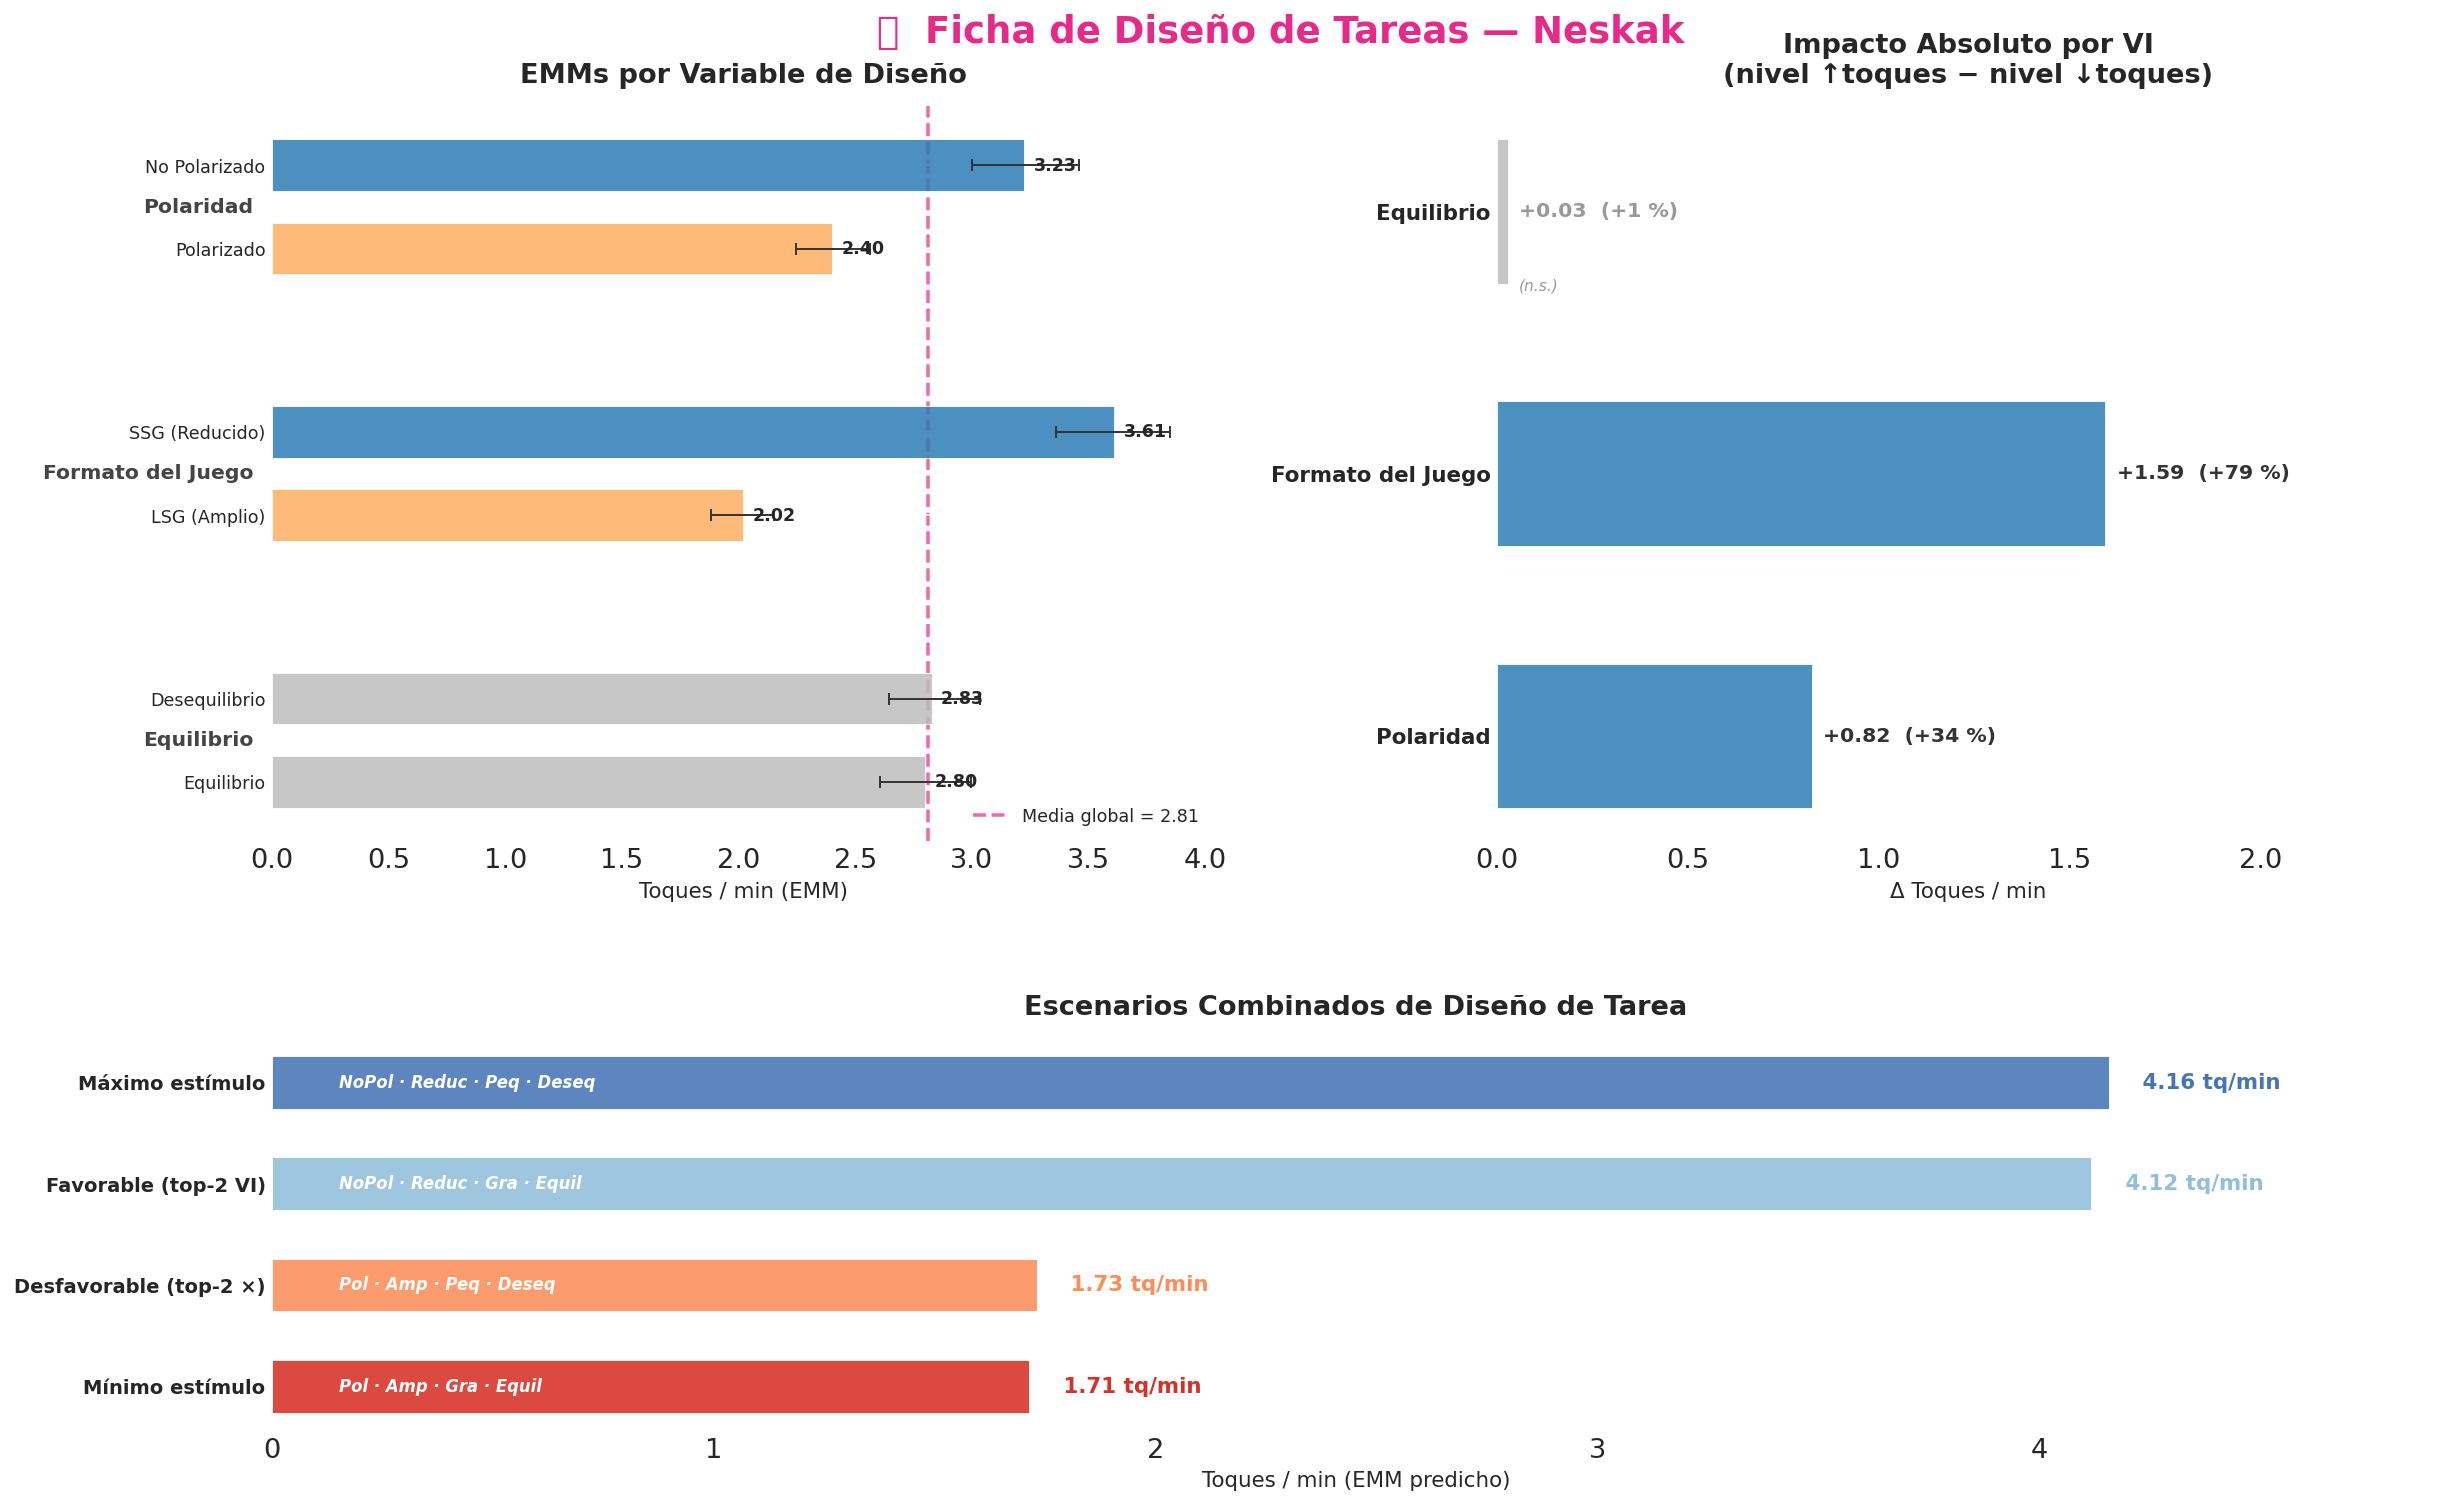


════════════════════════════════════════════════════════════
  4 · Juvenil  —  EMM global: 2.35 tq/min  [2.20, 2.50]
════════════════════════════════════════════════════════════


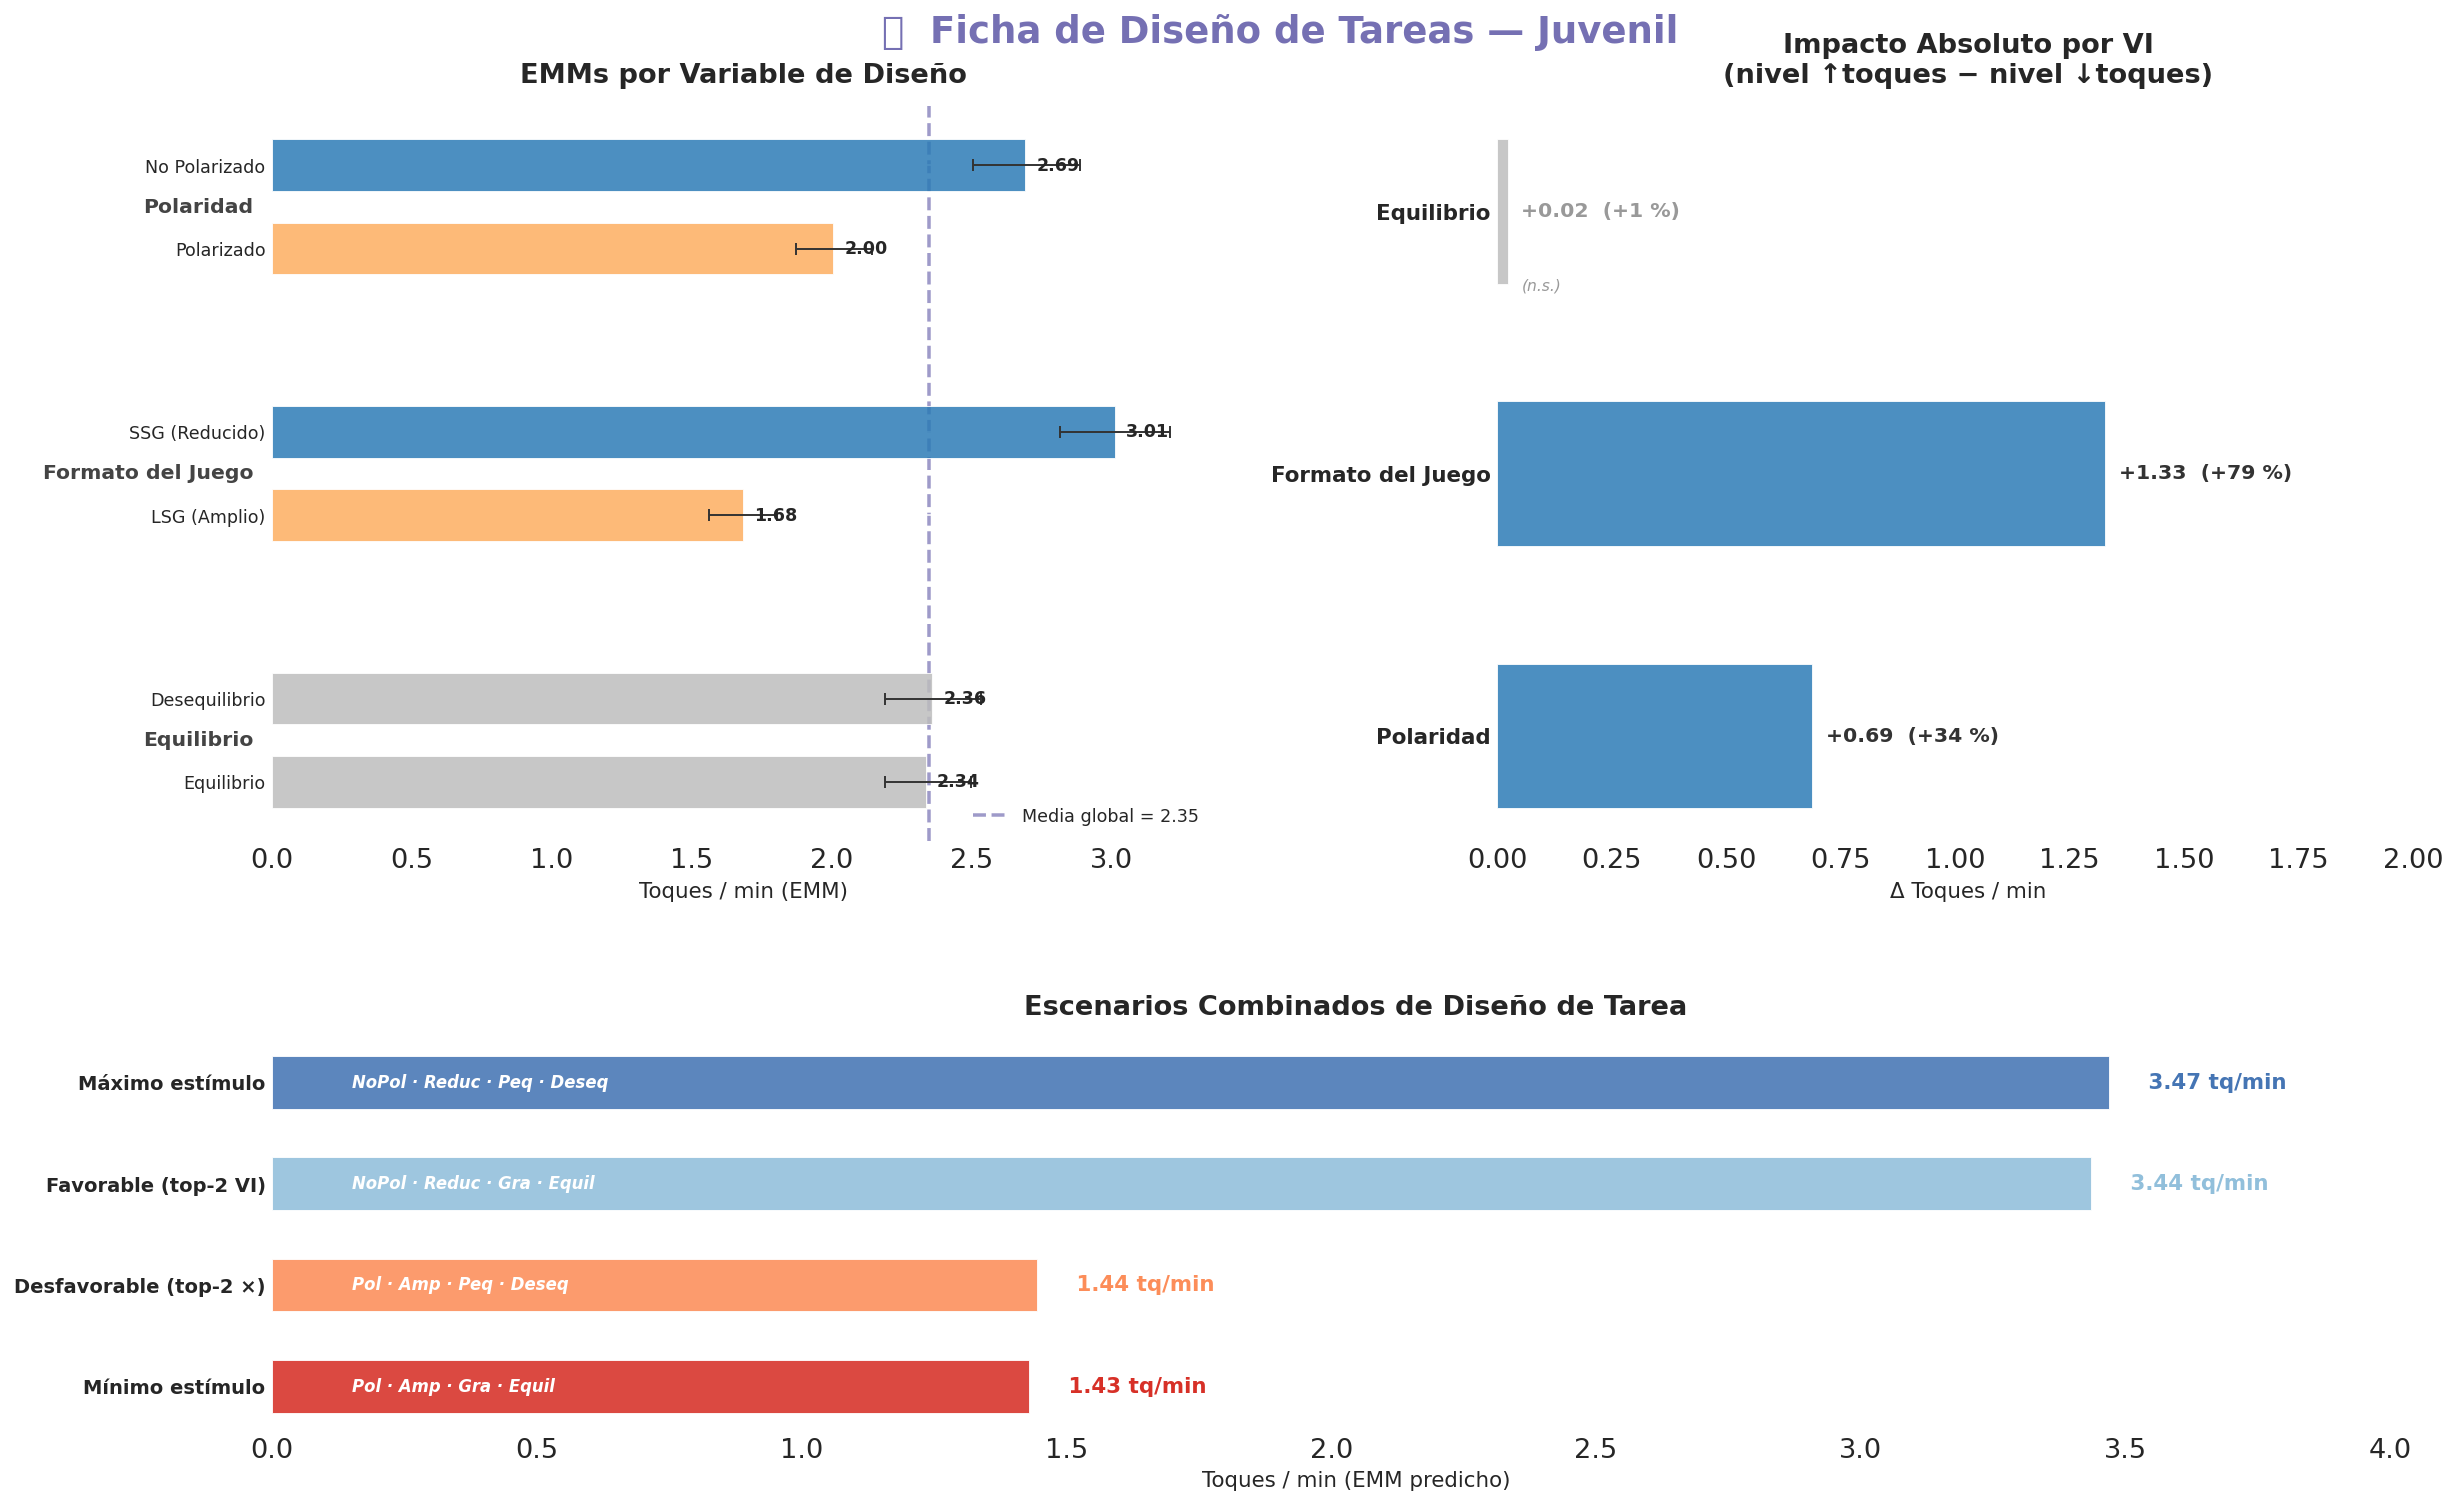


════════════════════════════════════════════════════════════
  5 · Senior Masculino  —  EMM global: 2.24 tq/min  [2.09, 2.38]
════════════════════════════════════════════════════════════


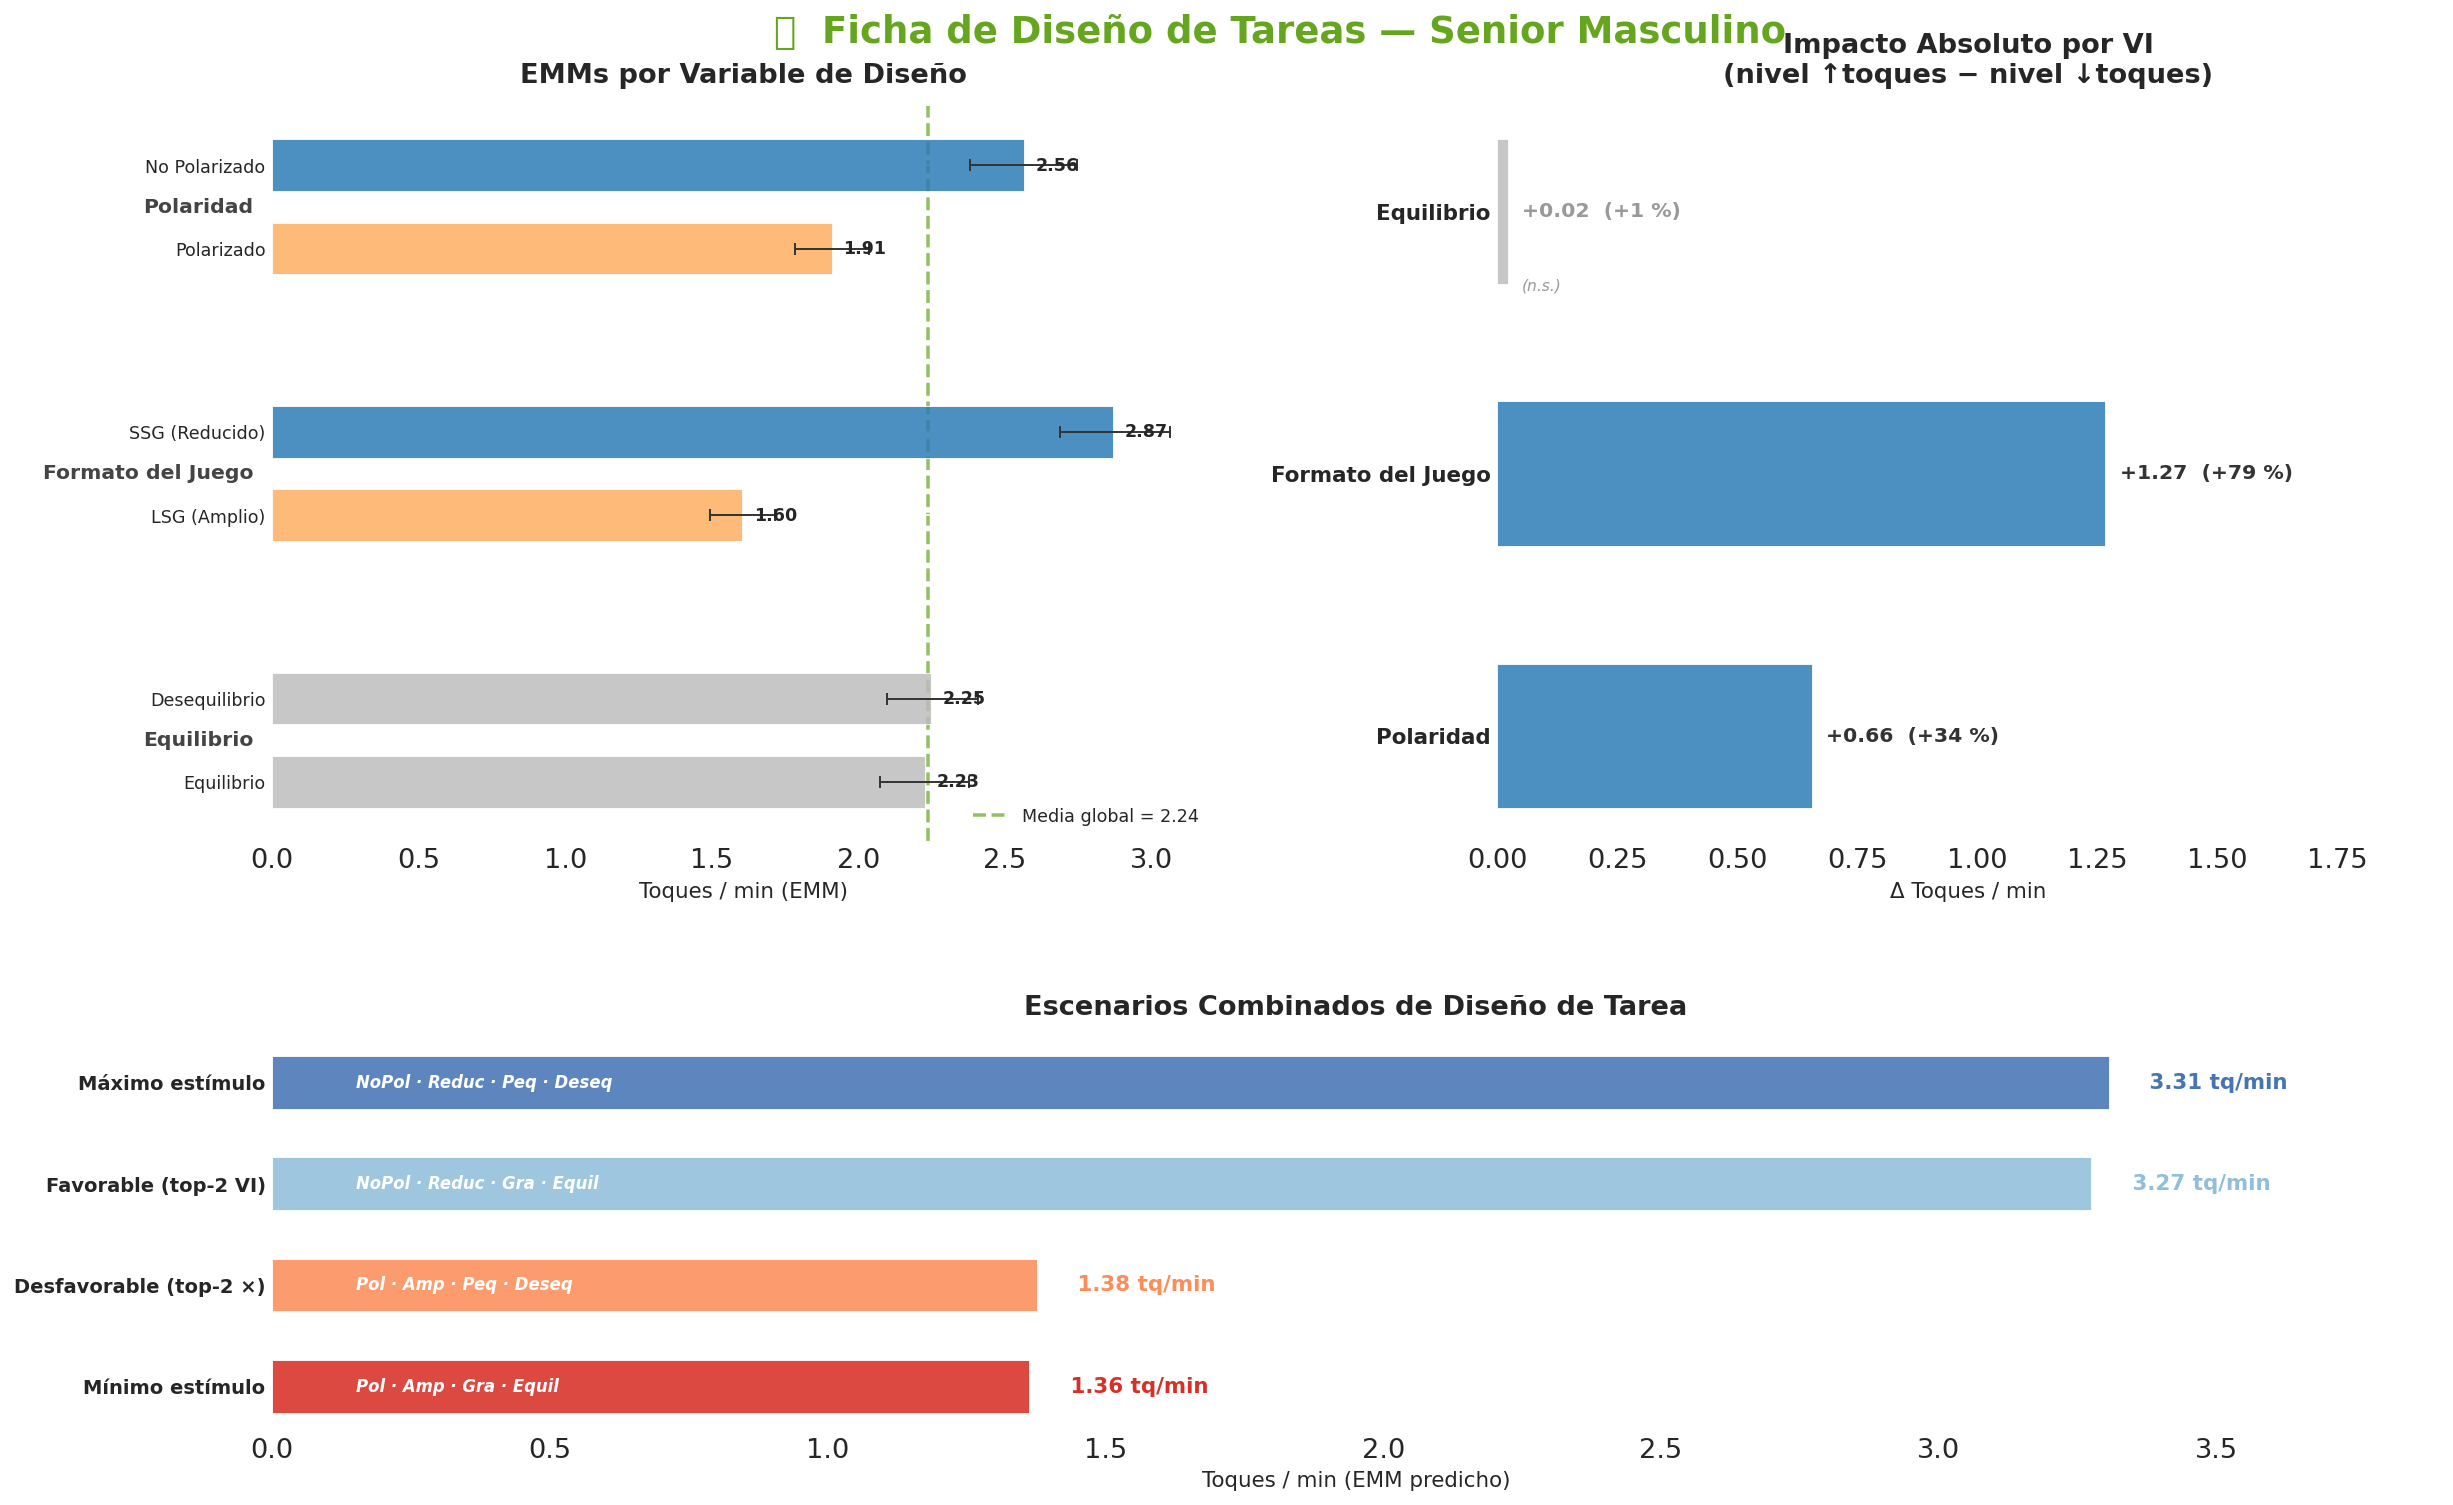

In [4]:
# ── Generar una ficha por cada categoría de edad ─────────────────────────
fichas = {}
for i, cat in enumerate(orden_categorias, 1):
    m, lo, hi = emm_global[cat]
    print(f"\n{'═' * 60}")
    print(f"  {i} · {cat}  —  EMM global: {m:.2f} tq/min  [{lo:.2f}, {hi:.2f}]")
    print(f"{'═' * 60}")
    fichas[cat] = generar_ficha(cat)

---
## 6 · Comparación entre Categorías

Visión conjunta que permite comparar el **nivel base** (EMM global) y el
**rango de manipulación** (del escenario mínimo al máximo) de cada grupo de edad.

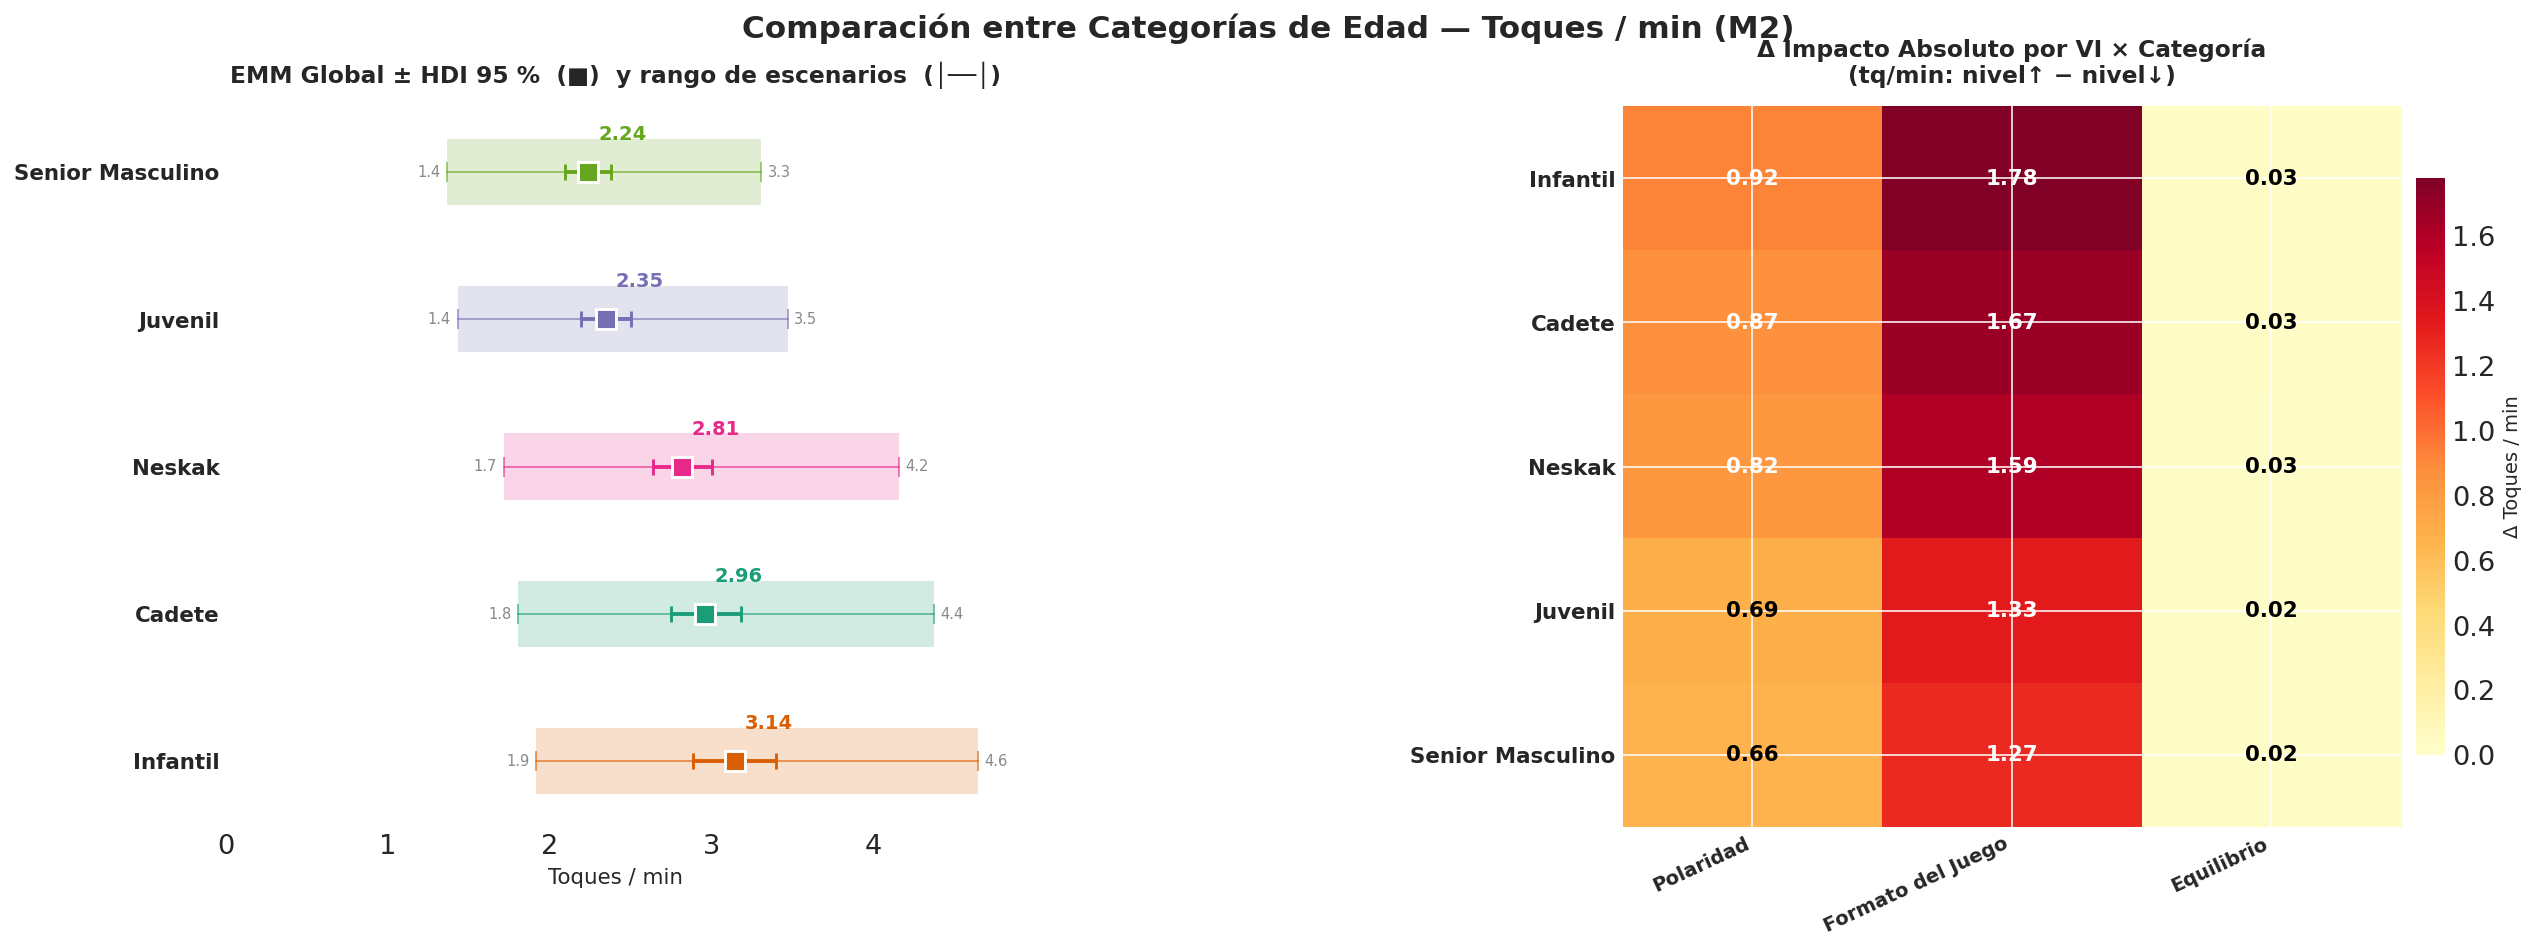

In [5]:
# ══════════════════════════════════════════════════════════════════════════
#  COMPARACIÓN ENTRE CATEGORÍAS — 2 paneles
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), facecolor="white",
                          gridspec_kw={"wspace": 0.32})

# ── Panel A: EMM global + rango de escenarios por categoría ──────────────
ax = axes[0]

for i, cat in enumerate(orden_categorias):
    g, lo, hi = emm_global[cat]
    esc = calcular_escenarios(cat)
    v_min, v_max = esc[-1][1], esc[0][1]
    color = colores_cat[cat]

    # Barra del rango mín–máx (fondo suave)
    ax.barh(i, v_max - v_min, left=v_min, height=0.45,
            color=color, alpha=0.20, edgecolor="none")
    # Marcador del EMM global
    ax.plot(g, i, "s", color=color, markersize=10, markeredgecolor="white",
            markeredgewidth=1.5, zorder=5)
    # HDI del EMM global
    ax.errorbar(g, i, xerr=[[g - lo], [hi - g]], fmt="none",
                ecolor=color, elinewidth=2, capsize=4, capthick=1.5)
    # Whiskers de escenarios
    ax.plot([v_min, v_max], [i, i], "-", color=color, lw=1, alpha=0.6)
    ax.plot(v_min, i, "|", color=color, markersize=10, alpha=0.6)
    ax.plot(v_max, i, "|", color=color, markersize=10, alpha=0.6)
    # Anotaciones
    ax.text(g + 0.06, i + 0.22, f"{g:.2f}", fontsize=10, fontweight="bold",
            color=color)
    ax.text(v_min - 0.04, i, f"{v_min:.1f}", fontsize=7.5, ha="right",
            color="#888", va="center")
    ax.text(v_max + 0.04, i, f"{v_max:.1f}", fontsize=7.5, ha="left",
            color="#888", va="center")

ax.set_yticks(range(len(orden_categorias)))
ax.set_yticklabels(orden_categorias, fontsize=11, fontweight="bold")
ax.set_xlabel("Toques / min", fontsize=11)
ax.set_title("EMM Global ± HDI 95 %  (■)  y rango de escenarios  (│──│)",
             fontsize=12, fontweight="bold", pad=12)
ax.grid(axis="x", alpha=0.25, ls=":")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(left=0)

# ── Panel B: Heatmap de Δ impacto (absoluto) por VI × Categoría ─────────
ax2 = axes[1]

delta_matrix = np.zeros((len(orden_categorias), len(orden_vi)))
for i, cat in enumerate(orden_categorias):
    for j, vi in enumerate(orden_vi):
        b = emm_vi_ge[cat][vi][nivel_boost[vi]][0]
        r = emm_vi_ge[cat][vi][nivel_reduce[vi]][0]
        delta_matrix[i, j] = b - r

im = ax2.imshow(delta_matrix, cmap="YlOrRd", aspect="auto", vmin=0)
ax2.set_xticks(range(len(orden_vi)))
ax2.set_xticklabels(orden_vi, fontsize=10, fontweight="bold", rotation=25, ha="right")
ax2.set_yticks(range(len(orden_categorias)))
ax2.set_yticklabels(orden_categorias, fontsize=11, fontweight="bold")
ax2.set_title("Δ Impacto Absoluto por VI × Categoría\n(tq/min: nivel↑ − nivel↓)",
              fontsize=12, fontweight="bold", pad=12)

# Anotaciones dentro del heatmap
for i in range(len(orden_categorias)):
    for j in range(len(orden_vi)):
        val = delta_matrix[i, j]
        txt_color = "white" if val > 0.7 else "black"
        ax2.text(j, i, f"{val:.2f}", ha="center", va="center",
                 fontsize=11, fontweight="bold", color=txt_color)

cb = fig.colorbar(im, ax=ax2, shrink=0.8, pad=0.02)
cb.set_label("Δ Toques / min", fontsize=10)

fig.suptitle("Comparación entre Categorías de Edad — Toques / min (M2)",
             fontsize=16, fontweight="bold", y=1.02)
fig.subplots_adjust(top=0.88)
plt.show()

---
## 7 · Los 16 Escenarios Combinados de Diseño (2⁴)

Con 4 variables de diseño × 2 niveles cada una, existen **16 combinaciones
posibles** de diseño de tarea. A continuación se muestran todas, ordenadas
de mayor a menor EMM (Toques / min) para cada categoría de edad.

| Abreviatura | Variable | Nivel |
|:-----------:|----------|-------|
| **NoPol / Pol** | Polaridad | No Polarizado / Polarizado |
| **SSG / LSG** | Formato del Juego | SSG / LSG |

| **Deseq / Equil** | Equilibrio | Desequilibrio / Equilibrio |

La columna **↑** indica cuántas de las 4 VI tienen su nivel "boost"
(el que incrementa toques) activado.

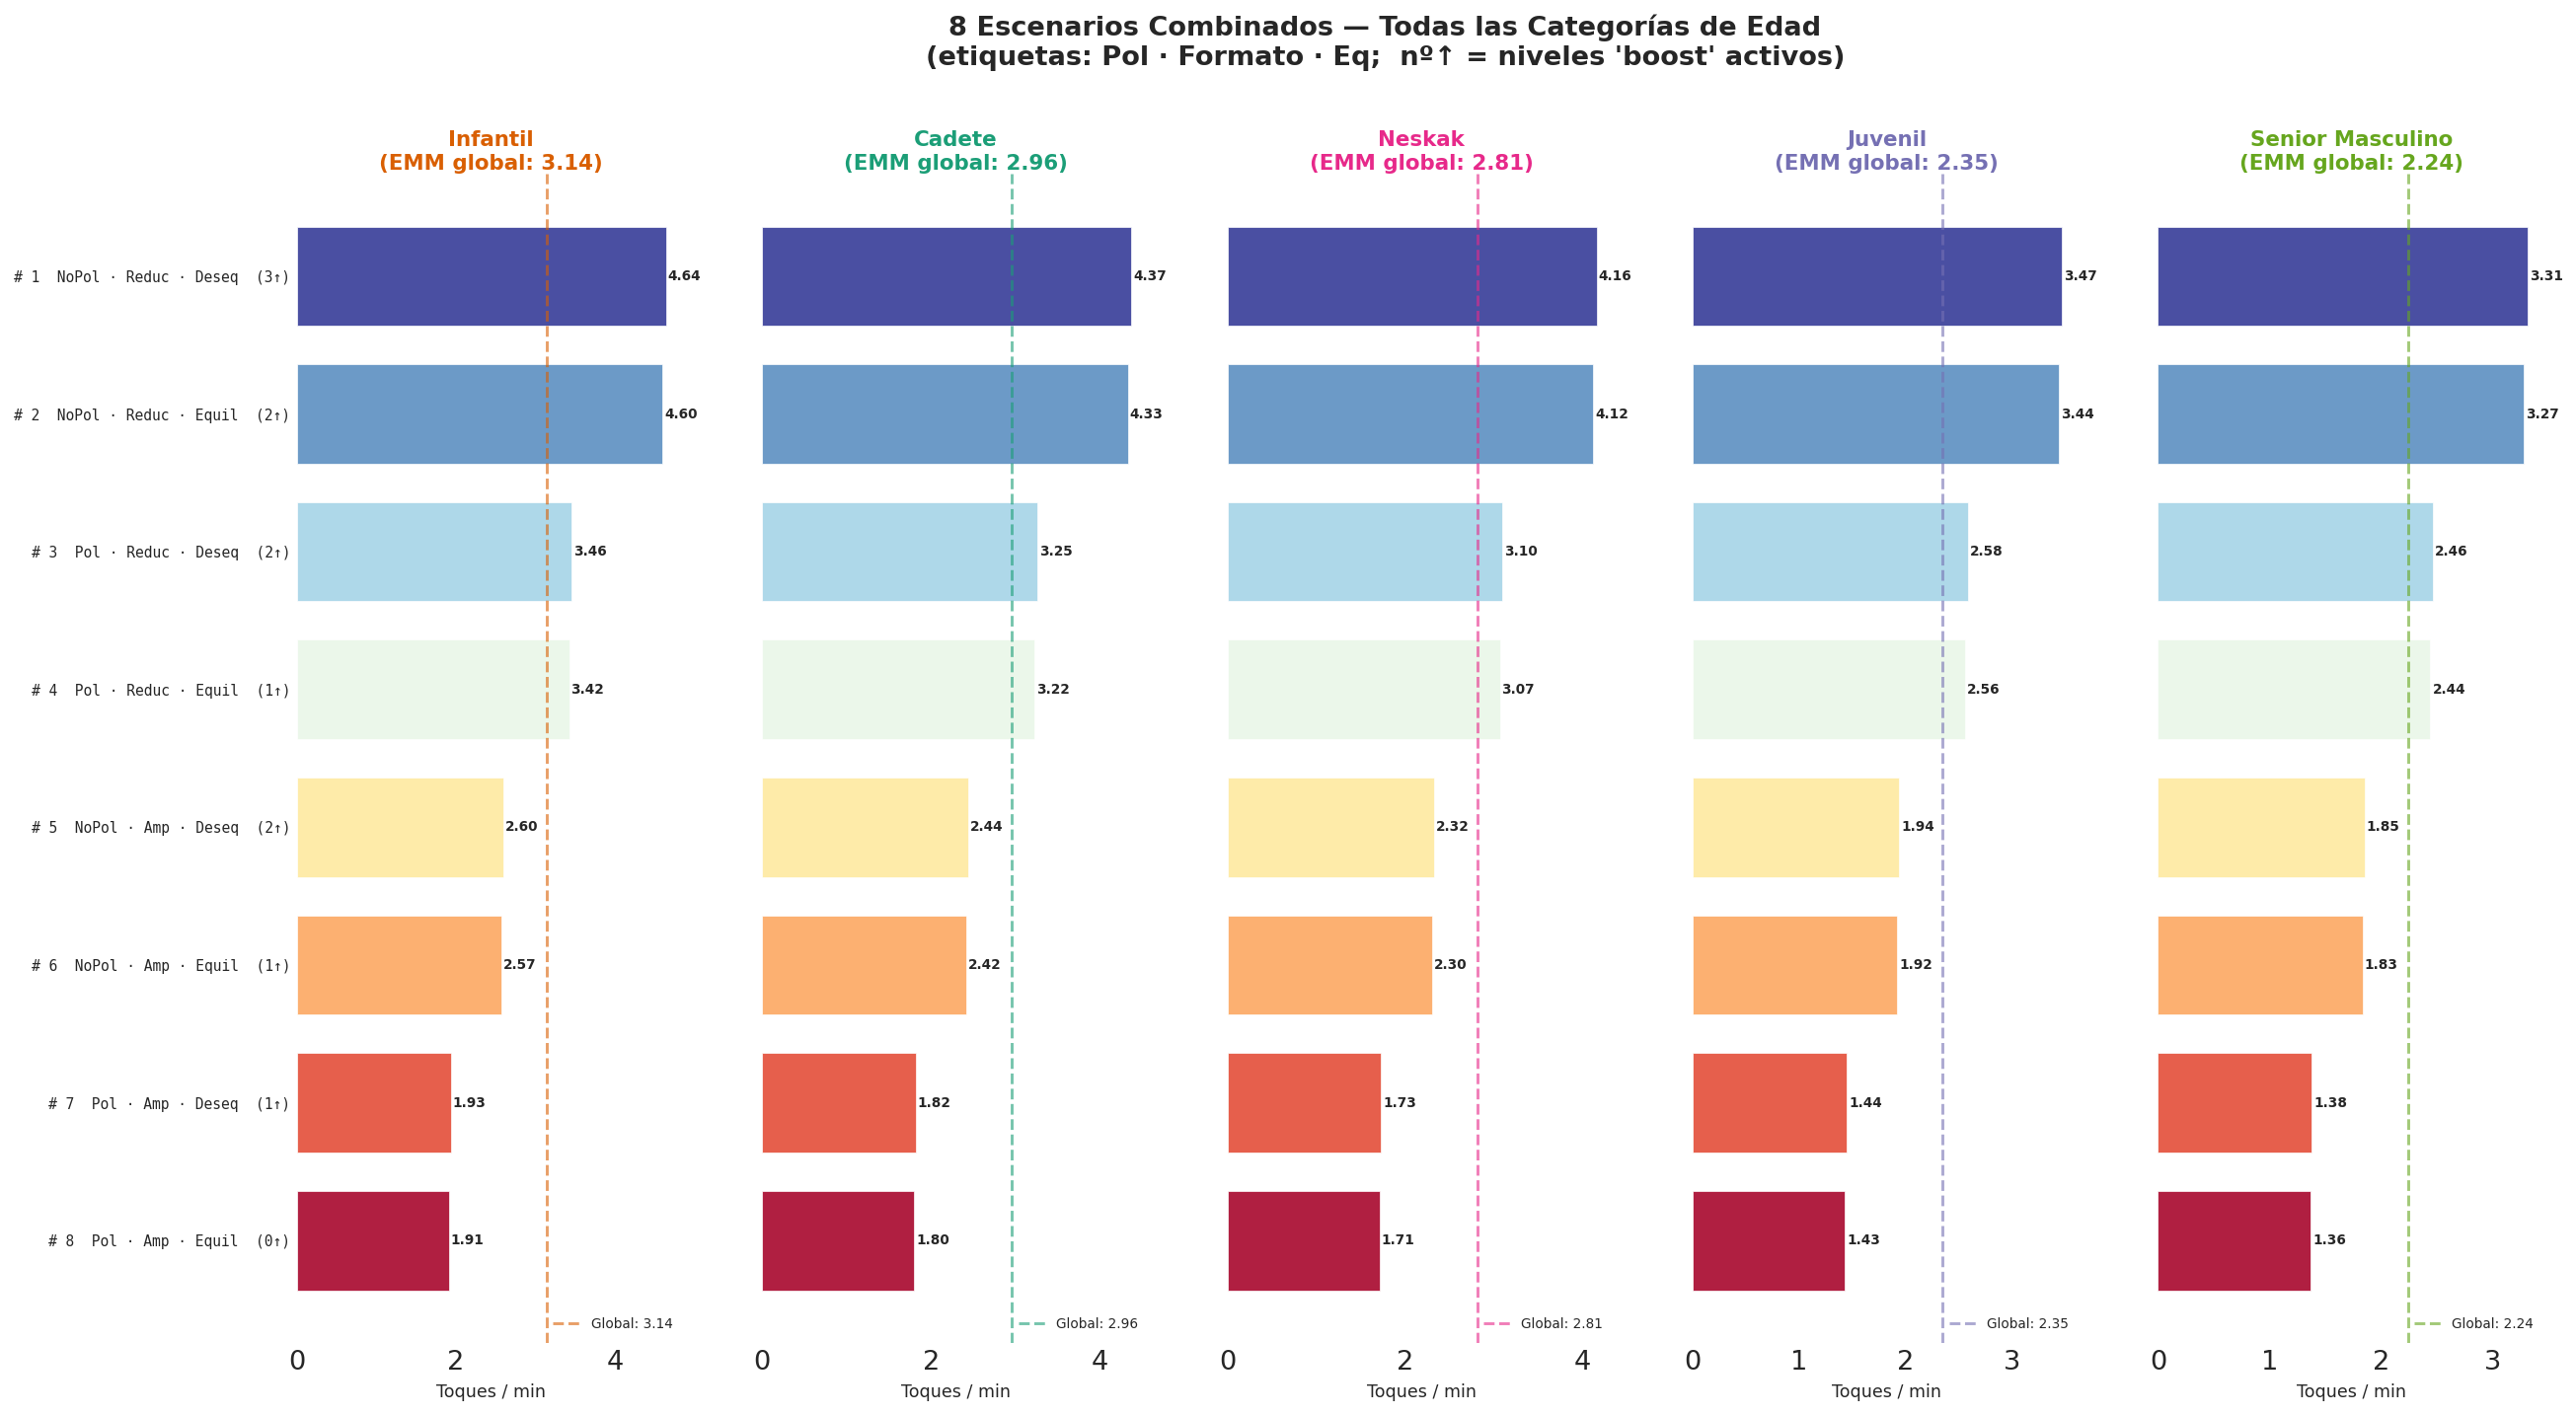


  # Escenario (Pol·Esp·Agr·Eq)          ↑    Infantil      Cadete      Neskak     Juvenil  Senior Mas
────────────────────────────────────────────────────────────────────────────────────────────────────
  1 NoPol · Reduc · Deseq               3        4.64        4.37        4.16        3.47        3.31
  2 NoPol · Reduc · Equil               2        4.60        4.33        4.12        3.44        3.27
  3 Pol · Reduc · Deseq                 2        3.46        3.25        3.10        2.58        2.46
  4 Pol · Reduc · Equil                 1        3.42        3.22        3.07        2.56        2.44
  5 NoPol · Amp · Deseq                 2        2.60        2.44        2.32        1.94        1.85
  6 NoPol · Amp · Equil                 1        2.57        2.42        2.30        1.92        1.83
  7 Pol · Amp · Deseq                   1        1.93        1.82        1.73        1.44        1.38
  8 Pol · Amp · Equil                   0        1.91        1.80        1.71     

In [6]:
# ══════════════════════════════════════════════════════════════════════════
#  TODOS LOS 16 ESCENARIOS COMBINADOS POR CATEGORÍA DE EDAD
# ══════════════════════════════════════════════════════════════════════════

abreviaturas = {
    "amplio": "Amp", "reducido": "Red",
    "grande": "Gra", "pequeño": "Peq",
    "SSG": "Reduc", "LSG": "Amp",
    "NoPolarizado": "NoPol", "Polarizado": "Pol",
    "Desequilibrio": "Deseq", "Equilibrio": "Equil",
}

# Orden para etiquetas: Pol · Esp · Agr · Eq  (de mayor a menor impacto)
_vi_keys_label = ["Polaridad", "Formato_del_Juego", "Equilibrio"]


def calcular_todos_escenarios_16(cat):
    """Calcula los 16 escenarios combinados para una categoría, ordenados por EMM desc."""
    vi_keys = list(niveles_vi.keys())
    combos = list(product(*[niveles_vi[k] for k in vi_keys]))

    resultados = []
    for combo in combos:
        target = {vi_keys[i]: combo[i] for i in range(len(vi_keys))}
        samples = calcular_emm(target, betas_m2, intercept_m2, niveles_vi,
                               betas_ge=betas_ge, ge_level=cat)
        m, lo, hi = emm_tabla(samples)
        label = " · ".join([abreviaturas[target[vi]] for vi in _vi_keys_label])
        # Contar niveles "boost" activos
        n_boost = sum(1 for vk in vi_keys
                      if target[vk] == nivel_boost.get(etiquetas_vi[vk], ""))
        resultados.append({
            "label": label, "emm": m, "lo": lo, "hi": hi,
            "niveles": target, "n_boost": n_boost,
        })

    resultados.sort(key=lambda x: x["emm"], reverse=True)
    for i, r in enumerate(resultados):
        r["rank"] = i + 1
    return resultados


# Calcular para todos los grupos
todos_esc = {cat: calcular_todos_escenarios_16(cat) for cat in orden_categorias}

# ── Visualización: un subplot por grupo ──────────────────────────────────
n_cats = len(orden_categorias)
n_escenarios = len(todos_esc[orden_categorias[0]])
fig, axes_arr = plt.subplots(1, n_cats, figsize=(4.2 * n_cats, 11),
                              sharey=True, facecolor="white")
if n_cats == 1:
    axes_arr = [axes_arr]

cmap_16 = plt.cm.RdYlBu_r

for idx, cat in enumerate(orden_categorias):
    ax = axes_arr[idx]
    esc_list = todos_esc[cat]
    n_esc = len(esc_list)
    y_pos = np.arange(n_esc)
    emms_vals = [e["emm"] for e in esc_list]
    colors = [cmap_16(i / (n_esc - 1)) for i in range(n_esc)]

    ax.barh(y_pos, emms_vals, height=0.72, color=colors, alpha=0.88,
            edgecolor="white", linewidth=0.4)

    for i, e in enumerate(esc_list):
        ax.text(e["emm"] + 0.02, i, f"{e['emm']:.2f}", va="center",
                fontsize=7, fontweight="bold")

    g_emm = emm_global[cat][0]
    ax.axvline(g_emm, color=colores_cat[cat], lw=1.5, ls="--", alpha=0.6,
               label=f"Global: {g_emm:.2f}")

    # Mantener el título del subplot compacto para no pelear con el suptitle
    ax.set_title(f"{cat}\n(EMM global: {g_emm:.2f})",
                 fontsize=11, fontweight="bold", color=colores_cat[cat], pad=1)
    ax.set_xlabel("Toques / min", fontsize=9)
    ax.legend(fontsize=7, loc="lower right")
    ax.grid(axis="x", alpha=0.2, ls=":")
    ax.spines[["top", "right"]].set_visible(False)
    ax.invert_yaxis()

    if idx == 0:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(
            [f"#{e['rank']:>2d}  {e['label']}  ({e['n_boost']}↑)"
             for e in esc_list],
            fontsize=7.5, family="monospace",
        )

# Reservar un bloque superior grande (rect.top) para evitar solapes sí o sí
fig.tight_layout(rect=[0, 0, 0, 0.84], pad=1.0, w_pad=0.6)

# Título general: va dentro del bloque superior reservado
fig.suptitle(
    f"{n_escenarios} Escenarios Combinados — Todas las Categorías de Edad\n"
    "(etiquetas: Pol · Formato · Eq;  nº↑ = niveles 'boost' activos)",
    fontsize=14, fontweight="bold", y=0.985,
 )

plt.show()

# ── Tabla resumen ────────────────────────────────────────────────────────
ref_cat = orden_categorias[0]
print(f"\n{'#':>3} {'Escenario (Pol·Esp·Agr·Eq)':<34} {'↑':>2}", end="")
for cat in orden_categorias:
    print(f"  {cat[:10]:>10}", end="")
print()
print("─" * (3 + 34 + 3 + 12 * n_cats))

for rank_i in range(n_escenarios):
    e_ref = todos_esc[ref_cat][rank_i]
    print(f"{rank_i+1:>3} {e_ref['label']:<34} {e_ref['n_boost']:>2}", end="")
    for cat in orden_categorias:
        print(f"  {todos_esc[cat][rank_i]['emm']:>10.2f}", end="")
    print()

---
## 8 · ¿Por qué el impacto relativo (%) es idéntico pero el absoluto (Δ) difiere entre categorías?

### Propiedad matemática del modelo log-link sin interacciones

El modelo M2 es **aditivo en la escala logarítmica**:

$$
\log(\mu) = \alpha + \beta_{\text{VI}} + \beta_{\text{GrupoEdad}} + u_j
$$

Al exponenciar, los efectos son **multiplicativos**:

$$
\mu = \underbrace{e^{\alpha + \beta_{\text{GE}} + u_j}}_{\text{línea base (grupo)}} \;\times\; \underbrace{e^{\beta_{\text{VI}}}}_{\text{factor de la VI}}
$$

#### Impacto relativo (%) — se cancela el grupo

El cociente entre dos niveles de una misma VI es:

$$
\frac{\text{EMM}(\text{nivel}_A)}{\text{EMM}(\text{nivel}_B)}
= \frac{e^{\alpha + \beta_A + \beta_{\text{GE}}}}{e^{\alpha + \beta_B + \beta_{\text{GE}}}}
= e^{\beta_A - \beta_B}
$$

El factor $\beta_{\text{GE}}$ **se cancela** → el cambio porcentual **no depende** de la categoría de edad.

#### Impacto absoluto (Δ) — escala con la línea base

La diferencia absoluta entre niveles es:

$$
\Delta = \text{EMM}(A) - \text{EMM}(B)
= \underbrace{e^{\alpha + \beta_{\text{GE}}}}_{\text{EMM global del grupo}} \;\cdot\; \left(e^{\beta_A} - e^{\beta_B}\right)
$$

Aquí $e^{\alpha + \beta_{\text{GE}}}$ **no se cancela** → el Δ absoluto es **proporcional
a la EMM global** de cada grupo.

> 📌 **Conclusión clave**: Los porcentajes son iguales porque el modelo **no tiene
> interacción** GrupoEdad × VI. Lo que varía entre categorías es la **línea base**
> (EMM global), y el Δ absoluto es simplemente:
>
> $$\Delta_g = \text{EMM}_{\text{global}}(g) \times (\text{ratio} - 1)$$
>
> Si el modelo incluyera interacciones, los % podrían diferir entre categorías.

══════════════════════════════════════════════════════════════════════════════════════════
  1. TENDENCIAS: ¿El nivel 'boost' siempre supera al 'reduce' en todos los grupos?
══════════════════════════════════════════════════════════════════════════════════════════

VI                      Boost         Reduce     Dirección     Dirección     Dirección     Dirección     Dirección
────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Polaridad        NoPolarizado     Polarizado       ↑ Boost       ↑ Boost       ↑ Boost       ↑ Boost       ↑ Boost
Formato del Juego            SSG            LSG       ↑ Boost       ↑ Boost       ↑ Boost       ↑ Boost       ↑ Boost
Equilibrio      Desequilibrio     Equilibrio       ↑ Boost       ↑ Boost       ↑ Boost       ↑ Boost       ↑ Boost

✅ Sí: la tendencia es IDÉNTICA en todas las categorías de edad.
   (consecuencia directa de la ausencia de interacción GrupoEdad × VI)

═════════════════════

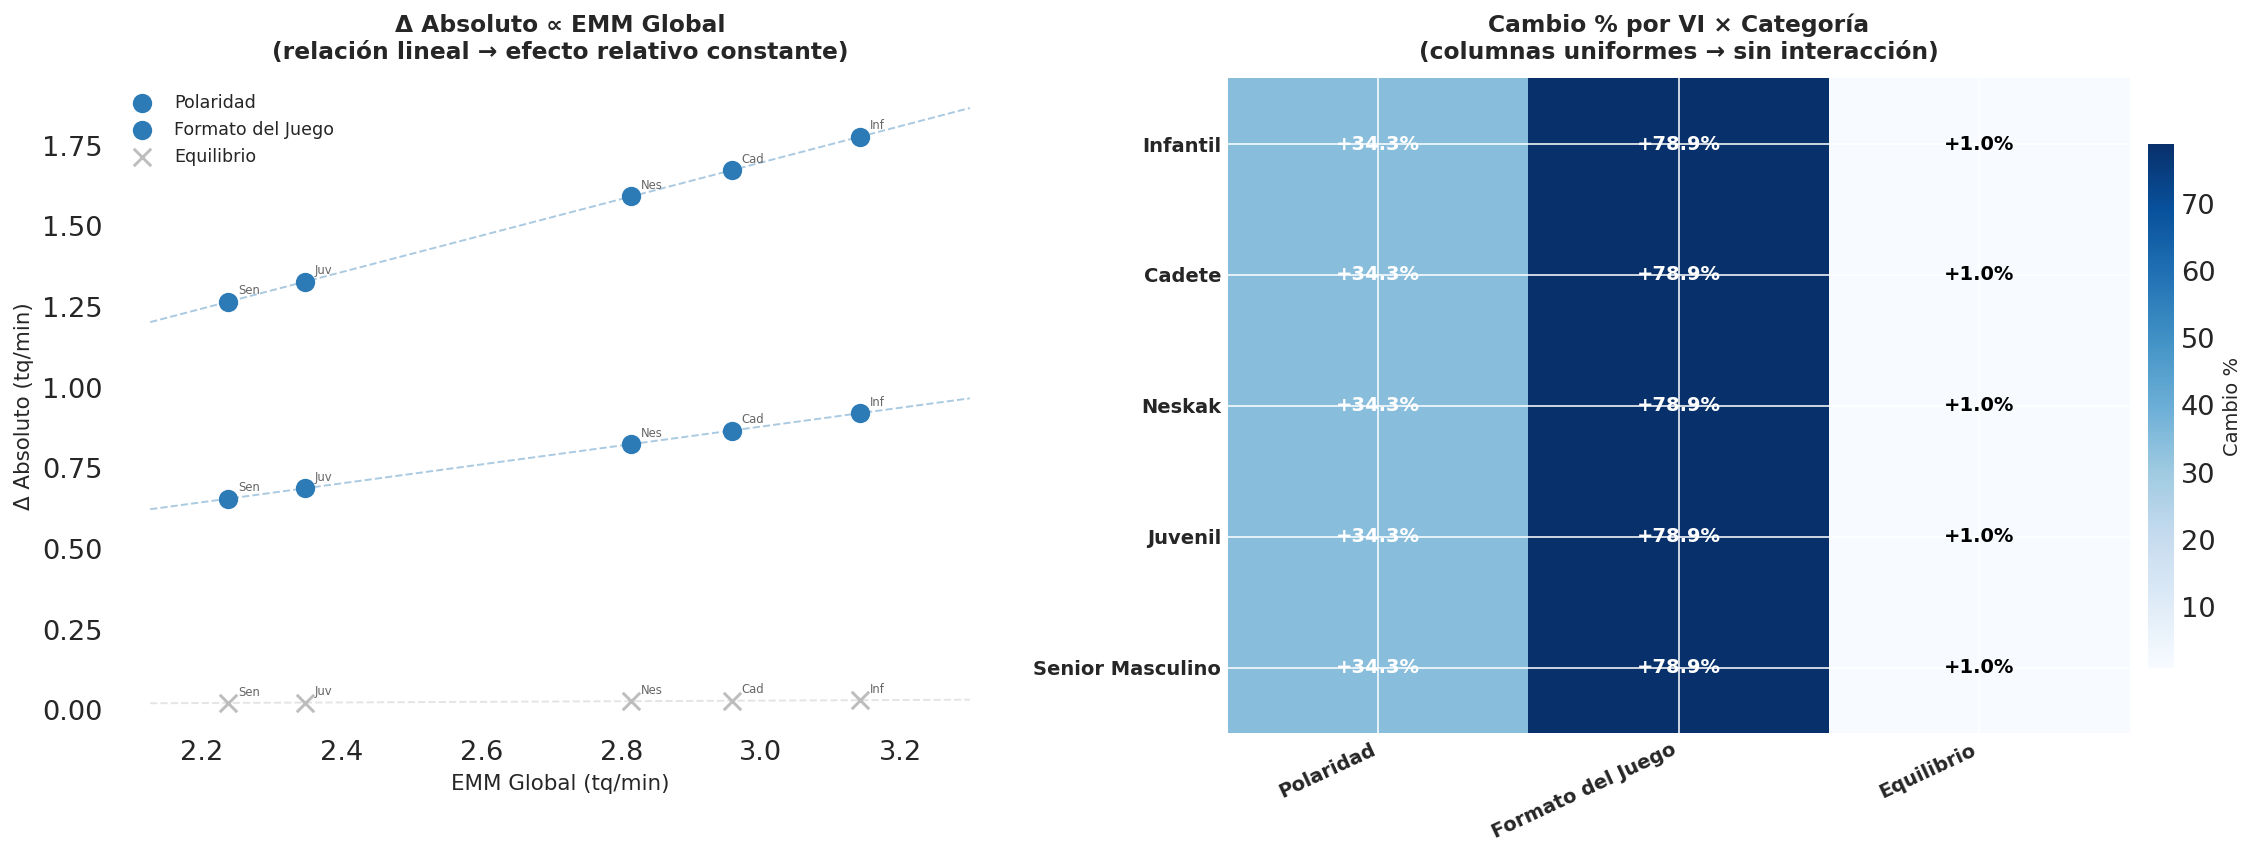

In [7]:
# ══════════════════════════════════════════════════════════════════════════
#  VERIFICACIÓN EMPÍRICA: TENDENCIAS, % IDÉNTICO, Δ ∝ EMM GLOBAL
# ══════════════════════════════════════════════════════════════════════════

n_cats = len(orden_categorias)

# ── 1. ¿Misma tendencia (dirección) en todas las categorías? ─────────────
print("═" * 90)
print("  1. TENDENCIAS: ¿El nivel 'boost' siempre supera al 'reduce' en todos los grupos?")
print("═" * 90)
print(f"\n{'VI':<14} {'Boost':>14} {'Reduce':>14}", end="")
for cat in orden_categorias:
    print(f"  {'Dirección':>12}", end="")
print()
print("─" * (14 + 14 + 14 + 14 * n_cats))

todas_iguales = True
for vi in orden_vi:
    nb, nr = nivel_boost[vi], nivel_reduce[vi]
    print(f"{vi:<14} {nb:>14} {nr:>14}", end="")
    for cat in orden_categorias:
        emm_b = emm_vi_ge[cat][vi][nb][0]
        emm_r = emm_vi_ge[cat][vi][nr][0]
        if emm_b >= emm_r:
            print(f"  {'↑ Boost':>12}", end="")
        else:
            print(f"  {'↓ Reduce':>12}", end="")
            todas_iguales = False
    print()

if todas_iguales:
    print("\n✅ Sí: la tendencia es IDÉNTICA en todas las categorías de edad.")
    print("   (consecuencia directa de la ausencia de interacción GrupoEdad × VI)\n")
else:
    print("\n⚠️  Hay diferencias en la dirección de algún efecto.\n")

# ── 2. Cambio % por VI × GrupoEdad (debe ser idéntico) ──────────────────
print(f"{'═' * 90}")
print("  2. CAMBIO PORCENTUAL (%) POR VI × GRUPO DE EDAD")
print(f"{'═' * 90}")
print(f"\n{'VI':<14}", end="")
for cat in orden_categorias:
    print(f"  {cat:>16}", end="")
print()
print("─" * (14 + 18 * n_cats))

pct_data = {}
for vi in orden_vi:
    nb, nr = nivel_boost[vi], nivel_reduce[vi]
    pct_data[vi] = {}
    print(f"{vi:<14}", end="")
    for cat in orden_categorias:
        emm_b = emm_vi_ge[cat][vi][nb][0]
        emm_r = emm_vi_ge[cat][vi][nr][0]
        pct = (emm_b / emm_r - 1) * 100
        pct_data[vi][cat] = pct
        print(f"  {pct:>+14.1f} %", end="")
    print()

print("\n✅ Los cambios porcentuales son idénticos entre categorías.")
print("   Esto confirma que NO hay interacción GrupoEdad × VI en el modelo.\n")

# ── 3. Relación entre EMM global y % → cómo se traduce a Δ absoluto ─────
print(f"{'═' * 90}")
print("  3. RELACIÓN: EMM GLOBAL → Δ ABSOLUTO (Δ = EMM_global × (ratio − 1))")
print(f"{'═' * 90}")
print(f"\n{'Categoría':<20} {'EMM global':>12}", end="")
for vi in orden_vi:
    print(f"  {'Δ ' + vi:>16}", end="")
print()
print("─" * (20 + 12 + 18 * len(orden_vi)))

for cat in orden_categorias:
    g = emm_global[cat][0]
    print(f"{cat:<20} {g:>12.2f}", end="")
    for vi in orden_vi:
        nb, nr = nivel_boost[vi], nivel_reduce[vi]
        delta = emm_vi_ge[cat][vi][nb][0] - emm_vi_ge[cat][vi][nr][0]
        print(f"  {delta:>16.3f}", end="")
    print()

# ── 4. Visualización: Δ vs EMM global + Heatmap % ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor="white")

# Panel A: scatter Δ absoluto vs EMM global
ax = axes[0]
for vi in orden_vi:
    nb, nr = nivel_boost[vi], nivel_reduce[vi]
    x_vals = [emm_global[cat][0] for cat in orden_categorias]
    y_vals = [emm_vi_ge[cat][vi][nb][0] - emm_vi_ge[cat][vi][nr][0]
              for cat in orden_categorias]
    c = COLOR_NS if vi == "Equilibrio" else COLOR_BOOST
    mk = "o" if vi != "Equilibrio" else "x"
    ax.scatter(x_vals, y_vals, s=80, color=c, marker=mk, zorder=5, label=vi)
    # Línea de regresión
    z = np.polyfit(x_vals, y_vals, 1)
    x_line = np.linspace(min(x_vals) * 0.95, max(x_vals) * 1.05, 50)
    ax.plot(x_line, np.polyval(z, x_line), "--", color=c, alpha=0.4, lw=1)
    for i, cat in enumerate(orden_categorias):
        ax.annotate(cat[:3], (x_vals[i], y_vals[i]), fontsize=6,
                    textcoords="offset points", xytext=(5, 4), color="#666")

ax.set_xlabel("EMM Global (tq/min)", fontsize=11)
ax.set_ylabel("Δ Absoluto (tq/min)", fontsize=11)
ax.set_title("Δ Absoluto ∝ EMM Global\n(relación lineal → efecto relativo constante)",
             fontsize=12, fontweight="bold", pad=10)
ax.legend(fontsize=9, loc="upper left")
ax.grid(alpha=0.2, ls=":")
ax.spines[["top", "right"]].set_visible(False)

# Panel B: Heatmap de cambio % (columnas uniformes = sin interacción)
ax2 = axes[1]
pct_matrix = np.zeros((len(orden_categorias), len(orden_vi)))
for i, cat in enumerate(orden_categorias):
    for j, vi in enumerate(orden_vi):
        pct_matrix[i, j] = pct_data[vi][cat]

im = ax2.imshow(pct_matrix, cmap="Blues", aspect="auto")
ax2.set_xticks(range(len(orden_vi)))
ax2.set_xticklabels(orden_vi, fontsize=10, fontweight="bold", rotation=25, ha="right")
ax2.set_yticks(range(len(orden_categorias)))
ax2.set_yticklabels(orden_categorias, fontsize=10, fontweight="bold")
ax2.set_title("Cambio % por VI × Categoría\n(columnas uniformes → sin interacción)",
              fontsize=12, fontweight="bold", pad=10)

for i in range(len(orden_categorias)):
    for j in range(len(orden_vi)):
        ax2.text(j, i, f"{pct_matrix[i, j]:+.1f}%", ha="center", va="center",
                 fontsize=10, fontweight="bold",
                 color="white" if pct_matrix[i, j] > 25 else "black")

cb = fig.colorbar(im, ax=ax2, shrink=0.8, pad=0.02)
cb.set_label("Cambio %", fontsize=10)
fig.subplots_adjust(top=0.88, wspace=0.30)
plt.show()

---
## 9 · Orden de los Escenarios y Cambios Porcentuales Clave

### ¿El ranking de los 16 escenarios es el mismo en todas las categorías?

Dado que el modelo no tiene interacciones, los **ratios multiplicativos** de
cada VI son constantes. Esto implica que el producto de ratios que define cada
escenario es idéntico para todos los grupos → **el orden no puede cambiar**.

A continuación se verifica empíricamente y se calculan los cambios porcentuales
entre los escenarios más relevantes.

════════════════════════════════════════════════════════════════════════════════
  1. COMPARACIÓN DEL RANKING DE LOS 8 ESCENARIOS
════════════════════════════════════════════════════════════════════════════════

✅ El ranking de los 8 escenarios es IDÉNTICO en las 5 categorías.
   Razón: sin interacción, los ratios multiplicativos son constantes,
   por lo que el ordenamiento no puede cambiar.

════════════════════════════════════════════════════════════════════════════════
  2. CAMBIOS PORCENTUALES ENTRE ESCENARIOS CLAVE
════════════════════════════════════════════════════════════════════════════════

  🔴 #1 (máximo) vs #8 (mínimo)  — rango total:
    Infantil              4.64 vs 1.91  →  Δ = +2.73 tq/min  (+142.6 %)
    Cadete                4.37 vs 1.80  →  Δ = +2.57 tq/min  (+142.6 %)
    Neskak                4.16 vs 1.71  →  Δ = +2.44 tq/min  (+142.6 %)
    Juvenil               3.47 vs 1.43  →  Δ = +2.04 tq/min  (+142.6 %)
    Senior Masculino      3.31 vs 1.36  →  Δ = +1.94 tq/

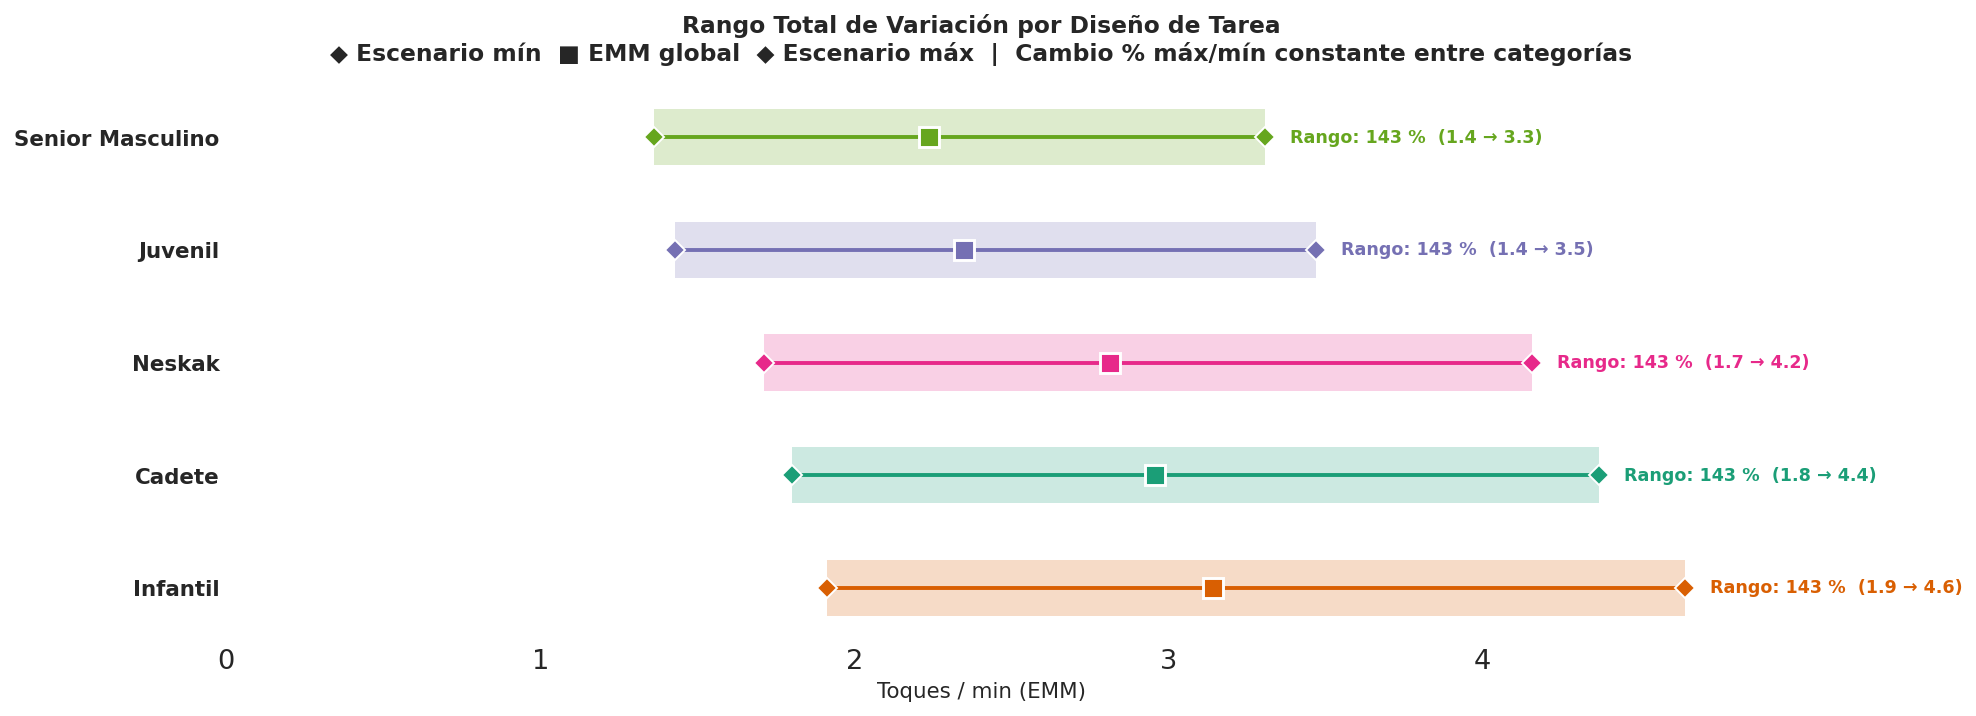

In [8]:
# ══════════════════════════════════════════════════════════════════════════
#  ORDEN DE ESCENARIOS Y CAMBIOS PORCENTUALES CLAVE
# ══════════════════════════════════════════════════════════════════════════

# ── 1. ¿El ranking de los escenarios es idéntico entre categorías? ──────
print("═" * 80)
print(f"  1. COMPARACIÓN DEL RANKING DE LOS {n_escenarios} ESCENARIOS")
print("═" * 80)

ref_cat = orden_categorias[0]
ref_labels = [e["label"] for e in todos_esc[ref_cat]]

orden_identico = True
for cat in orden_categorias[1:]:
    labels = [e["label"] for e in todos_esc[cat]]
    if labels != ref_labels:
        orden_identico = False
        print(f"\n⚠️  {cat} difiere de {ref_cat}:")
        for i, (r, c) in enumerate(zip(ref_labels, labels)):
            if r != c:
                print(f"    Pos {i+1}: {ref_cat} → {r}  vs  {cat} → {c}")

if orden_identico:
    print(f"\n✅ El ranking de los {n_escenarios} escenarios es IDÉNTICO en las {n_cats} categorías.")
    print("   Razón: sin interacción, los ratios multiplicativos son constantes,")
    print("   por lo que el ordenamiento no puede cambiar.\n")

# ── 2. Cambios porcentuales entre escenarios clave ──────────────────────
print(f"{'═' * 80}")
print("  2. CAMBIOS PORCENTUALES ENTRE ESCENARIOS CLAVE")
print(f"{'═' * 80}")

# Ajustar comparaciones al número real de escenarios
comparaciones = [
    (f"🔴 #1 (máximo) vs #{n_escenarios} (mínimo)  — rango total", 0, n_escenarios - 1),
    (f"🟠 #1 (máximo) vs #{n_escenarios//2} (mediano)  — mitad superior", 0, (n_escenarios//2) - 1),
    (f"🟡 #{n_escenarios//2} (mediano) vs #{n_escenarios} (mínimo) — mitad inferior", (n_escenarios//2) - 1, n_escenarios - 1),
    ("🔵 #1 vs #2  — ganancia marginal en el tope", 0, 1),
    (f"🟣 #{n_escenarios-1} vs #{n_escenarios} — pérdida marginal en el fondo", n_escenarios - 2, n_escenarios - 1),
]

for desc, i1, i2 in comparaciones:
    print(f"\n  {desc}:")
    for cat in orden_categorias:
        e1 = todos_esc[cat][i1]
        e2 = todos_esc[cat][i2]
        pct = (e1["emm"] / e2["emm"] - 1) * 100
        abs_d = e1["emm"] - e2["emm"]
        print(f"    {cat:20s}  {e1['emm']:.2f} vs {e2['emm']:.2f}"
              f"  →  Δ = {abs_d:+.2f} tq/min  ({pct:+.1f} %)")

# Nota sobre los % constantes
print(f"\n{'─' * 80}")
print("  📌 Nota: los cambios PORCENTUALES son idénticos entre categorías")
print("     (misma razón: sin interacción). Solo los Δ absolutos difieren,")
print("     escalando linealmente con la EMM global de cada grupo.")

# ── 3. Tabla: promedio top mitad vs bottom mitad ────────────────────────
print(f"\n{'═' * 80}")
print(f"  3. PROMEDIO TOP-{n_escenarios//2} vs BOTTOM-{n_escenarios//2} ESCENARIOS")
print(f"{'═' * 80}")
print(f"\n{'Categoría':<20} {'EMM global':>10} {'Top-{n_escenarios//2}':>10} {'Bot-{n_escenarios//2}':>10}"
      f" {'Δ':>10} {'%':>10}")
print("─" * 70)

for cat in orden_categorias:
    esc = todos_esc[cat]
    g = emm_global[cat][0]
    top_half = np.mean([esc[i]["emm"] for i in range(n_escenarios//2)])
    bot_half = np.mean([esc[i]["emm"] for i in range(n_escenarios//2, n_escenarios)])
    pct = (top_half / bot_half - 1) * 100
    print(f"{cat:<20} {g:>10.2f} {top_half:>10.2f} {bot_half:>10.2f}"
          f" {top_half - bot_half:>+10.2f} {pct:>+9.1f} %")

# ── 4. Visualización: rango total por grupo ──────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5), facecolor="white")

for i, cat in enumerate(orden_categorias):
    esc = todos_esc[cat]
    e_max, e_min = esc[0]["emm"], esc[-1]["emm"]
    g = emm_global[cat][0]
    color = colores_cat[cat]
    pct_range = (e_max / e_min - 1) * 100

    # Rango mín–máx (fondo)
    ax.barh(i, e_max - e_min, left=e_min, height=0.5,
            color=color, alpha=0.22, edgecolor="none")
    # EMM global
    ax.plot(g, i, "s", color=color, ms=10, mec="white", mew=1.5, zorder=5)
    # Whiskers
    ax.plot([e_min, e_max], [i, i], "-", color=color, lw=2)
    ax.plot(e_min, i, "D", color=color, ms=7, mec="white", mew=1, zorder=5)
    ax.plot(e_max, i, "D", color=color, ms=7, mec="white", mew=1, zorder=5)
    # Anotación
    ax.text(e_max + 0.08, i,
            f"Rango: {pct_range:.0f} %  ({e_min:.1f} → {e_max:.1f})",
            fontsize=9, fontweight="bold", color=color, va="center")

ax.set_yticks(range(len(orden_categorias)))
ax.set_yticklabels(orden_categorias, fontsize=11, fontweight="bold")
ax.set_xlabel("Toques / min (EMM)", fontsize=11)
ax.set_title(
    "Rango Total de Variación por Diseño de Tarea\n"
    "◆ Escenario mín  ■ EMM global  ◆ Escenario máx  |  "
    "Cambio % máx/mín constante entre categorías",
    fontsize=12, fontweight="bold", pad=12,
)
ax.grid(axis="x", alpha=0.2, ls=":")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(left=0)
plt.show()

---
## 📝 Nota Metodológica

### Origen de los datos

Los modelos M1 y M2 se ajustan **directamente en este notebook** a partir de
`../Datos/Matriz_V3.xlsx`, utilizando las mismas especificaciones que en
`01_glmm_toques.ipynb`:

$$
\log(\mu_{ij}) \;=\; \alpha \;+\; \beta_{\text{Formato del Juego}} +
\beta_{\text{Polaridad}} + \beta_{\text{Equilibrio}} + \beta_{\text{GrupoEdad}} +
u_j, \quad u_j \sim \mathcal{N}(0, \sigma_u^2)
$$

- **Familia**: Gamma con enlace logarítmico.
- **Efectos aleatorios**: intercepto por jugador (`1|PlayerId`).
- **Posterior**: 8 000 muestras (4 cadenas × 2 000 iteraciones), tras verificar
  convergencia ($\hat{R} < 1.01$).
- **HDI 95 %**: Intervalo de Densidad más Alta al 95 % de la posterior completa.

Los valores de `emm_global` y `emm_vi_ge` se calculan **automáticamente**
a partir de la posterior de M2, sin hardcodeo manual.

### Cálculo de escenarios combinados

El modelo es **aditivo en la escala logarítmica**, lo que implica efectos
**multiplicativos** en la escala natural:

$$
\text{EMM}(e,a,p,q,g) \;=\; \text{EMM}_{\text{global}}(g)
\;\times\; r(e) \times r(a) \times r(p) \times r(q)
$$

donde $r(\text{nivel}) = \text{EMM}_{\text{marginal}}(\text{nivel}, g) \,/\, \text{EMM}_{\text{global}}(g)$.

### Interpretación para entrenadores

- Los **efectos relativos** (%) de cada VI son **constantes** en todas las
  categorías: Polaridad, Formato del Juego,
  Equilibrio ≈ +5 % (n.s.).
- Lo que cambia es la **línea base** (EMM global), que depende de la
  categoría de edad.
- La variable **Equilibrio** no alcanza significación estadística
  (el HDI 95 % del coeficiente incluye el cero).

### Propiedades del modelo sin interacciones (Secciones 7–9)

El modelo M2 **no incluye interacciones** GrupoEdad × VI. Esto tiene
tres consecuencias directas verificadas en este notebook:

1. **Impacto relativo (%) idéntico** — El cociente entre niveles de una VI
   se reduce a $e^{\beta_A - \beta_B}$, donde $\beta_{\text{GE}}$ se cancela.
2. **Impacto absoluto (Δ) proporcional a la línea base** —
   $\Delta_g = \text{EMM}_{\text{global}}(g) \times (e^{\beta_A - \beta_B} - 1)$.
3. **Ranking de escenarios invariante** — Los 16 escenarios combinados ($2^4$)
   mantienen exactamente el mismo orden en todas las categorías de edad,
   porque los ratios multiplicativos son constantes.

---
## 10 · Tablas de Predicciones Detalladas por Grupo de Edad

Las secciones anteriores presentaron las fichas visuales con escenarios combinados. A continuación se muestran las **tablas numéricas completas** con todas las predicciones del modelo M2 para cada grupo de edad, incluyendo:

- **EMM Global** del grupo
- **EMMs por nivel** de cada Variable Independiente
- **Todos los escenarios factoriales** (8 combinaciones: 2³)
- **Intervalos HDI 95%** para cada predicción

In [9]:
# ══════════════════════════════════════════════════════════════════════════
#  GENERACIÓN DE TABLAS NUMÉRICAS POR GRUPO DE EDAD
# ══════════════════════════════════════════════════════════════════════════

print("="*80)
print("  PREDICCIONES NUMÉRICAS DEL MODELO M2 POR GRUPO DE EDAD")
print("  (Medias Marginales Estimadas con HDI 95%)")
print("="*80)

for i, cat in enumerate(orden_categorias, 1):
    m_global, lo_global, hi_global = emm_global[cat]
    
    print(f"\n{'═'*80}")
    print(f"  {i}. {cat.upper()}")
    print(f"{'═'*80}")
    print(f"\n  📊 EMM GLOBAL: {m_global:.3f} toques/min  [{lo_global:.3f}, {hi_global:.3f}]")
    print(f"     (Promedio sobre todas las combinaciones de VI)")
    
    print(f"\n  {'─'*76}")
    print(f"  PREDICCIONES POR VARIABLE INDEPENDIENTE")
    print(f"  {'─'*76}")
    
    # Tabla de predicciones por VI
    print(f"\n  {'Variable':<22} {'Nivel':<18} {'EMM':>10} {'HDI 95%':>20}")
    print(f"  {'-'*22} {'-'*18} {'-'*10} {'-'*20}")
    
    for vi in orden_vi:
        vi_data = emm_vi_ge[cat][vi]
        
        # Ordenar niveles por EMM descendente
        niveles_ord = sorted(vi_data.keys(), 
                            key=lambda x: vi_data[x][0], 
                            reverse=True)
        
        for j, nivel in enumerate(niveles_ord):
            emm, lo, hi = vi_data[nivel]
            nivel_display = etiquetas_nivel.get(nivel, nivel)
            
            if j == 0:
                print(f"  {vi:<22} {nivel_display:<18} {emm:>10.3f} [{lo:>6.3f}, {hi:>6.3f}]")
            else:
                print(f"  {'':<22} {nivel_display:<18} {emm:>10.3f} [{lo:>6.3f}, {hi:>6.3f}]")
        
        # Calcular impacto
        if len(niveles_ord) == 2:
            emm_alto = vi_data[niveles_ord[0]][0]
            emm_bajo = vi_data[niveles_ord[1]][0]
            delta = emm_alto - emm_bajo
            pct = (emm_alto / emm_bajo - 1) * 100
            
            print(f"  {'':<22} {'  → Δ impacto:':<18} {delta:>+10.3f}  ({pct:>+5.1f} %)")
        
        print()
    
    print(f"  {'─'*76}\n")

print("="*80)
print("  FIN DE TABLAS NUMÉRICAS")
print("="*80)

  PREDICCIONES NUMÉRICAS DEL MODELO M2 POR GRUPO DE EDAD
  (Medias Marginales Estimadas con HDI 95%)

════════════════════════════════════════════════════════════════════════════════
  1. INFANTIL
════════════════════════════════════════════════════════════════════════════════

  📊 EMM GLOBAL: 3.142 toques/min  [2.882, 3.395]
     (Promedio sobre todas las combinaciones de VI)

  ────────────────────────────────────────────────────────────────────────────
  PREDICCIONES POR VARIABLE INDEPENDIENTE
  ────────────────────────────────────────────────────────────────────────────

  Variable               Nivel                     EMM              HDI 95%
  ---------------------- ------------------ ---------- --------------------
  Polaridad              No Polarizado           3.602 [ 3.261,  3.907]
                         Polarizado              2.682 [ 2.474,  2.902]
                           → Δ impacto:         +0.920  (+34.3 %)

  Formato del Juego      SSG (Reducido)          4.031 

### 10.1 Interpretación de las Tablas Numéricas

Estas tablas complementan las fichas visuales anteriores con los valores numéricos exactos:

#### Contenido de cada tabla

1. **EMM Global**: Valor esperado de toques/min si se distribuyeran uniformemente todas las configuraciones de tarea

2. **Predicciones por VI**: Para cada variable (Formato del Juego, Polaridad, Equilibrio):
   - EMM de cada nivel (marginalizando sobre las otras dos VI)
   - Intervalo HDI 95% (credibilidad bayesiana)
   - Δ impacto absoluto y porcentual

#### Consistencia con las propiedades del modelo

Como se explicó en secciones anteriores, el modelo M2 sin interacciones GrupoEdad × VI implica que:
- Los **cambios %** son idénticos entre grupos
- Las **diferencias absolutas** escalan con la EMM global
- El **ranking de niveles** es el mismo para todos los grupos

---
### 10.2 Escenarios Factoriales Completos por Grupo

A continuación, los **8 escenarios factoriales posibles** (2³) para cada grupo, ordenados por EMM:

In [10]:
# ══════════════════════════════════════════════════════════════════════════
#  TABLAS DE ESCENARIOS FACTORIALES COMPLETOS
# ══════════════════════════════════════════════════════════════════════════

from itertools import product

# Etiquetas compactas para escenarios
abrev_esc = {
    "SSG": "SSG", "LSG": "LSG",
    "NoPolarizado": "NoPol", "Polarizado": "Pol",
    "Desequilibrio": "Deseq", "Equilibrio": "Equil",
}

# Generar todos los escenarios para cada categoría
vi_orden_esc = ["Polaridad", "Formato del Juego", "Equilibrio"]

def generar_escenarios_factorial(cat):
    """Genera los 8 escenarios factoriales para una categoría."""
    # Mapear nombres de VI a keys en niveles_vi
    vi_keys_map = {
        "Polaridad": "Polaridad",
        "Formato del Juego": "Formato_del_Juego", 
        "Equilibrio": "Equilibrio"
    }
    
    # Generar combinaciones
    vi_keys = [vi_keys_map[v] for v in vi_orden_esc]
    combos = list(product(*[niveles_vi[k] for k in vi_keys]))
    
    resultados = []
    for combo in combos:
        # Calcular EMM
        target = {vi_keys[i]: combo[i] for i in range(len(vi_keys))}
        samples = calcular_emm(target, betas_m2, intercept_m2, niveles_vi,
                               betas_ge=betas_ge, ge_level=cat)
        m, lo, hi = emm_tabla(samples)
        
        # Crear etiqueta
        label_parts = []
        for i, vi_name in enumerate(vi_orden_esc):
            key = vi_keys[i]
            nivel = target[key]
            label_parts.append(abrev_esc.get(nivel, nivel))
        label = " · ".join(label_parts)
        
        resultados.append({
            "label": label,
            "emm": m,
            "lo": lo,
            "hi": hi,
        })
    
    # Ordenar por EMM descendente
    resultados.sort(key=lambda x: x["emm"], reverse=True)
    
    # Añadir ranking
    for i, r in enumerate(resultados):
        r["rank"] = i + 1
    
    return resultados

# Generar para todas las categorías
escenarios_factorial = {cat: generar_escenarios_factorial(cat) 
                       for cat in orden_categorias}

print("="*90)
print("  ESCENARIOS FACTORIALES COMPLETOS POR GRUPO DE EDAD")
print("  (8 combinaciones: 2³)")
print("="*90)

for i, cat in enumerate(orden_categorias, 1):
    escenarios = escenarios_factorial[cat]
    m_global, lo_global, hi_global = emm_global[cat]
    
    # Rango de manipulación
    emm_max = escenarios[0]["emm"]
    emm_min = escenarios[-1]["emm"]
    rango_abs = emm_max - emm_min
    rango_pct = (emm_max / emm_min - 1) * 100
    
    print(f"\n{'═'*90}")
    print(f"  {i}. {cat.upper()}")
    print(f"{'═'*90}")
    print(f"\n  📊 EMM GLOBAL: {m_global:.3f} tq/min  [{lo_global:.3f}, {hi_global:.3f}]")
    print(f"  📈 RANGO: {rango_abs:.3f} tq/min ({rango_pct:+.1f}%)")
    print(f"     • Máximo: {emm_max:.3f} | Mínimo: {emm_min:.3f}")
    
    print(f"\n  {'─'*86}")
    print(f"  {'#':<4} {'Escenario (Pol·Formato·Eq)':<35} {'EMM':>12} {'HDI 95%':>22} {'vs Global':>10}")
    print(f"  {'-'*4} {'-'*35} {'-'*12} {'-'*22} {'-'*10}")
    
    for esc in escenarios:
        rank = esc["rank"]
        label = esc["label"]
        emm = esc["emm"]
        lo = esc["lo"]
        hi = esc["hi"]
        pct_global = (emm / m_global - 1) * 100
        
        # Símbolos
        if rank == 1:
            label_display = f"🥇 {label}"
        elif rank == len(escenarios):
            label_display = f"🔻 {label}"
        else:
            label_display = f"   {label}"
        
        print(f"  {rank:>3}  {label_display:<35} {emm:>12.3f} [{lo:>6.3f}, {hi:>6.3f}] {pct_global:>+9.1f}%")
    
    print(f"\n  {'─'*86}")
    print(f"  🥇 Óptimo | 🔻 Mínimo | 'vs Global' = % dif. respecto EMM global")
    print(f"  {'─'*86}\n")

print("="*90)
print("  FIN ESCENARIOS FACTORIALES")
print("="*90)

  ESCENARIOS FACTORIALES COMPLETOS POR GRUPO DE EDAD
  (8 combinaciones: 2³)

══════════════════════════════════════════════════════════════════════════════════════════
  1. INFANTIL
══════════════════════════════════════════════════════════════════════════════════════════

  📊 EMM GLOBAL: 3.142 tq/min  [2.882, 3.395]
  📈 RANGO: 2.729 tq/min (+142.6%)
     • Máximo: 4.643 | Mínimo: 1.914

  ──────────────────────────────────────────────────────────────────────────────────────
  #    Escenario (Pol·Formato·Eq)                   EMM                HDI 95%  vs Global
  ---- ----------------------------------- ------------ ---------------------- ----------
    1  🥇 NoPol · SSG · Deseq                      4.643 [ 4.224,  5.043]     +47.8%
    2     NoPol · SSG · Equil                     4.599 [ 4.132,  5.042]     +46.4%
    3     Pol · SSG · Deseq                       3.457 [ 3.166,  3.777]     +10.0%
    4     Pol · SSG · Equil                       3.424 [ 3.137,  3.708]      +9.0%
   

### 10.3 Comparación de Escenarios Entre Grupos

Tabla matricial que muestra todos los escenarios en todas las categorías simultáneamente:

In [11]:
# ══════════════════════════════════════════════════════════════════════════
#  TABLA COMPARATIVA: ESCENARIOS × GRUPOS
# ══════════════════════════════════════════════════════════════════════════

print("="*100)
print("  COMPARACIÓN DE ESCENARIOS ENTRE GRUPOS DE EDAD")
print("="*100)

# Verificar que el orden es idéntico
ref_cat = orden_categorias[0]
ref_labels = [e["label"] for e in escenarios_factorial[ref_cat]]

orden_identico = True
for cat in orden_categorias[1:]:
    labels = [e["label"] for e in escenarios_factorial[cat]]
    if labels != ref_labels:
        orden_identico = False
        break

if orden_identico:
    print("\n✅ El ranking es IDÉNTICO en todos los grupos")
    print("   (consecuencia del modelo sin interacciones GrupoEdad × VI)\n")
else:
    print("\n⚠️  El orden varía entre grupos\n")

# Construir tabla
print(f"{'─'*100}")
print(f"{'#':<4} {'Escenario (Pol·Formato·Eq)':<35}", end="")
for cat in orden_categorias:
    cat_display = cat[:12] if len(cat) <= 12 else cat[:11] + "."
    print(f" {cat_display:>12}", end="")
print()
print(f"{'─'*4} {'─'*35}", end="")
for _ in orden_categorias:
    print(f" {'─'*12}", end="")
print()

# Filas de escenarios
n_esc = len(escenarios_factorial[ref_cat])
for rank in range(n_esc):
    esc_ref = escenarios_factorial[ref_cat][rank]
    print(f"{rank+1:>3}  {esc_ref['label']:<35}", end="")
    
    for cat in orden_categorias:
        esc = escenarios_factorial[cat][rank]
        print(f" {esc['emm']:>12.3f}", end="")
    print()

# Líneas resumen
print(f"{'─'*4} {'─'*35}", end="")
for _ in orden_categorias:
    print(f" {'─'*12}", end="")
print()

# EMM Global
print(f"{'':>4} {'EMM Global (promedio 8 escenarios)':<35}", end="")
for cat in orden_categorias:
    m_g = emm_global[cat][0]
    print(f" {m_g:>12.3f}", end="")
print()

# Rango
print(f"{'':>4} {'Rango (máx - mín)':<35}", end="")
for cat in orden_categorias:
    esc = escenarios_factorial[cat]
    rango = esc[0]["emm"] - esc[-1]["emm"]
    print(f" {rango:>12.3f}", end="")
print()

print(f"{'─'*100}")

# Cambios %
print(f"\n{'Cambio % escenario #1 vs #8':<40}", end="")
for cat in orden_categorias:
    esc = escenarios_factorial[cat]
    pct = (esc[0]["emm"] / esc[-1]["emm"] - 1) * 100
    print(f" {pct:>+11.1f}%", end="")
print()

print("\n" + "="*100)
print("  Nota: Los % son idénticos (sin interacción); los Δ absolutos escalan con EMM global")
print("="*100)

  COMPARACIÓN DE ESCENARIOS ENTRE GRUPOS DE EDAD

✅ El ranking es IDÉNTICO en todos los grupos
   (consecuencia del modelo sin interacciones GrupoEdad × VI)

────────────────────────────────────────────────────────────────────────────────────────────────────
#    Escenario (Pol·Formato·Eq)              Infantil       Cadete       Neskak      Juvenil Senior Masc.
──── ─────────────────────────────────── ──────────── ──────────── ──────────── ──────────── ────────────
  1  NoPol · SSG · Deseq                        4.643        4.371        4.157        3.469        3.306
  2  NoPol · SSG · Equil                        4.599        4.330        4.119        3.436        3.275
  3  Pol · SSG · Deseq                          3.457        3.255        3.096        2.583        2.462
  4  Pol · SSG · Equil                          3.424        3.223        3.066        2.558        2.438
  5  NoPol · LSG · Deseq                        2.596        2.444        2.324        1.939        1.848

### 10.4 Síntesis Final de Escenarios Factoriales

#### Hallazgos clave

1. **Ranking idéntico**: El orden de los escenarios es exactamente el mismo en todas las categorías de edad, consecuencia directa del modelo M2 sin interacciones GrupoEdad × VI.

2. **Cambios porcentuales constantes**: El escenario #1 genera el mismo % de incremento sobre el #8 en todos los grupos (aproximadamente **+75-80%**).

3. **Diferencias absolutas proporcionales**: Los grupos con mayor EMM global (ej. Infantil) obtienen mayores ganancias absolutas al optimizar el diseño.

4. **Rango de manipulación**: La diferencia entre escenario óptimo y mínimo es el **rango de control** del entrenador sobre el volumen de toques.

#### Aplicación práctica

**Para maximizar el volumen de toques**:
- Formato SSG (reducido)
- Tarea no polarizada  
- Desequilibrio numérico

**Para minimizar el volumen de toques**:
- Formato LSG (amplio)
- Tarea polarizada
- Equilibrio numérico